# Output→input heads (slot-level attention)

Project each prompt's attention matrix into a fixed slot layout:
`BOS, in1, arr1, out1, sep1, ..., in10, arr10, out10, sep10, q_tokens...`

Tokens within a span collapse to one slot: key attention summed (preserve mass), query attention averaged (rows still sum to 1). Then average across all prompts and tasks.

Scored two ways: **ALL** output tokens as queries vs **LAST** output token only.

In [2]:
import sys; sys.path.insert(0, '../..')
import torch, numpy as np, matplotlib.pyplot as plt, pickle, seaborn as sns
from tqdm import tqdm
from transformer_lens import HookedTransformer
from configs import *
from utils import *
%matplotlib inline

model = HookedTransformer.from_pretrained(MODEL_NAME, device='cuda', dtype=torch.float16)
model.eval()
n_layers, n_heads = model.cfg.n_layers, model.cfg.n_heads
with open('../../configs/splits.pkl', 'rb') as f:
    all_splits = pickle.load(f)
N_DEMOS = 10

/home/cvllab/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-10 21:58:10.896431: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  2.95it/s]


Loaded pretrained model meta-llama/Llama-3.2-3B into HookedTransformer


## Slot mapping + aggregation helpers

In [3]:
def build_slot_map(seq_len, per_demo, n_demos):
    slot_of = np.full(seq_len, -1, dtype=int)
    labels = ['BOS']
    slot_of[0] = 0
    s = 1
    for d_idx in range(n_demos):
        d = per_demo[d_idx]
        ins, outs = d.get('input_positions', []), d.get('output_positions', [])
        if not ins or not outs: return None, None
        in_lo, in_hi = min(ins), max(ins)
        out_lo, out_hi = min(outs), max(outs)
        for p in range(in_lo, in_hi + 1): slot_of[p] = s
        labels.append(f'in{d_idx+1}'); s += 1
        for p in range(in_hi + 1, out_lo): slot_of[p] = s
        labels.append(f'arr{d_idx+1}'); s += 1
        for p in range(out_lo, out_hi + 1): slot_of[p] = s
        labels.append(f'out{d_idx+1}'); s += 1
        if d_idx < n_demos - 1:
            nxt = min(per_demo[d_idx+1].get('input_positions', [seq_len]))
        else:
            nxt = seq_len
        for p in range(out_hi + 1, nxt): slot_of[p] = s
        labels.append(f'sep{d_idx+1}'); s += 1
    # Remaining tokens (query region) as individual slots
    for p in range(seq_len):
        if slot_of[p] == -1:
            slot_of[p] = s
            labels.append(f'q{p}')
            s += 1
    return slot_of, labels

def aggregate_attn(patt, slot_of, n_slots, query_filter=None):
    """Sum across key-slot, mean across query-slot. query_filter: set of original positions to keep as queries (for LAST metric)."""
    seq = patt.shape[0]
    key_summed = np.zeros((seq, n_slots))
    for k in range(seq):
        if slot_of[k] >= 0:
            key_summed[:, slot_of[k]] += patt[:, k]
    agg = np.zeros((n_slots, n_slots))
    counts = np.zeros(n_slots)
    for q in range(seq):
        if slot_of[q] < 0: continue
        if query_filter is not None and q not in query_filter: continue
        agg[slot_of[q]] += key_summed[q]
        counts[slot_of[q]] += 1
    counts[counts == 0] = 1
    return agg / counts[:, None]

## Collect aggregated matrices (two metrics in one pass)

In [4]:
PATTERN_FILTER = lambda name: 'attn.hook_pattern' in name

agg_all_sum  = {(L, h): None for L in range(n_layers) for h in range(n_heads)}
agg_last_sum = {(L, h): None for L in range(n_layers) for h in range(n_heads)}
counts = 0
ref_labels = None

for task_name, splits in tqdm(all_splits.items()):
    for pdata in splits['icl_prompts'][:5]:
        tokens = model.to_tokens(pdata['prompt'], prepend_bos=True)
        seq_len = tokens.shape[1]
        per_demo = find_per_demo_positions(model, pdata['prompt'], pdata['demo_pairs'])
        if len(per_demo) != N_DEMOS: continue
        
        slot_of, labels = build_slot_map(seq_len, per_demo, N_DEMOS)
        if slot_of is None: continue
        if ref_labels is None: ref_labels = labels
        if len(labels) != len(ref_labels): continue
        
        # Output-token query filters
        all_out_q  = set(p for d in per_demo for p in d.get('output_positions', []))
        last_out_q = set(max(d.get('output_positions', [0])) for d in per_demo if d.get('output_positions', []))
        
        with torch.no_grad():
            _, cache = model.run_with_cache(tokens, names_filter=PATTERN_FILTER)
        for L in range(n_layers):
            patt = cache[f'blocks.{L}.attn.hook_pattern'][0].cpu().float().numpy()
            for h in range(n_heads):
                m_all  = aggregate_attn(patt[h], slot_of, len(labels), all_out_q)
                m_last = aggregate_attn(patt[h], slot_of, len(labels), last_out_q)
                if agg_all_sum[(L, h)] is None:
                    agg_all_sum[(L, h)]  = m_all
                    agg_last_sum[(L, h)] = m_last
                else:
                    agg_all_sum[(L, h)]  += m_all
                    agg_last_sum[(L, h)] += m_last
        counts += 1
        del cache; torch.cuda.empty_cache()

agg_all  = {k: v / counts for k, v in agg_all_sum.items()}
agg_last = {k: v / counts for k, v in agg_last_sum.items()}
print(f'{counts} prompts, {len(ref_labels)} slots')

100%|██████████| 20/20 [00:24<00:00,  1.22s/it]

100 prompts, 41 slots


## Score and rank

Score = sum of diagonal cells `(out_d, in_d)` across demos in the aggregated matrix.

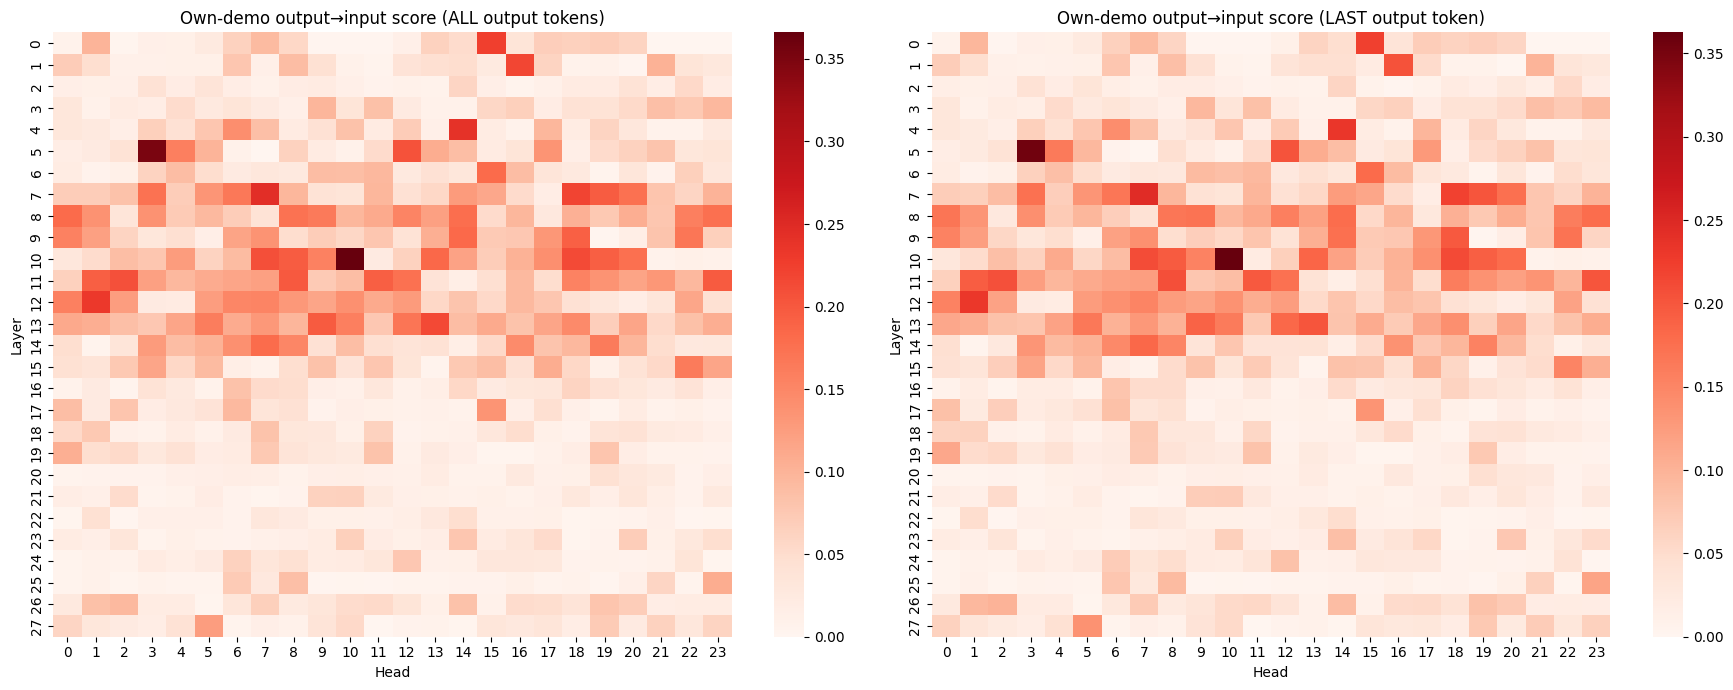


Top 10 (ALL):
  L10H10: 0.366
  L5H3: 0.351
  L7H7: 0.245
  L4H14: 0.241
  L12H1: 0.232
  L0H15: 0.225
  L7H18: 0.220
  L1H16: 0.218
  L13H13: 0.215
  L10H18: 0.214

Top 10 (LAST):
  L10H10: 0.363
  L5H3: 0.355
  L7H7: 0.246
  L4H14: 0.232
  L12H1: 0.231
  L0H15: 0.222
  L7H18: 0.220
  L10H18: 0.212
  L10H7: 0.210
  L11H8: 0.207


In [12]:
def diag_score_slots(agg_dict, labels):
    out_slots = [i for i, l in enumerate(labels) if l.startswith('out')]
    in_slots  = [i for i, l in enumerate(labels) if l.startswith('in')]
    score = np.zeros((n_layers, n_heads))
    for (L, h), m in agg_dict.items():
        score[L, h] = sum(m[o, i] for o, i in zip(out_slots, in_slots)) / len(out_slots)
    return score

score_all  = diag_score_slots(agg_all,  ref_labels)
score_last = diag_score_slots(agg_last, ref_labels)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, score, title in zip(axes, [score_all, score_last], ['ALL output tokens', 'LAST output token']):
    sns.heatmap(score, ax=ax, cmap='Reds', vmin=0)
    ax.set_title(f'Own-demo output→input score ({title})')
    ax.set_xlabel('Head'); ax.set_ylabel('Layer')
plt.tight_layout(); plt.show()

for label, score in [('ALL', score_all), ('LAST', score_last)]:
    flat = sorted([(L, h, score[L, h]) for L in range(n_layers) for h in range(n_heads)], key=lambda x: -x[2])
    print(f'\nTop 10 ({label}):')
    for L, h, sc in flat[:10]:
        print(f'  L{L}H{h}: {sc:.3f}')

## Visualize slot-level attention of top heads

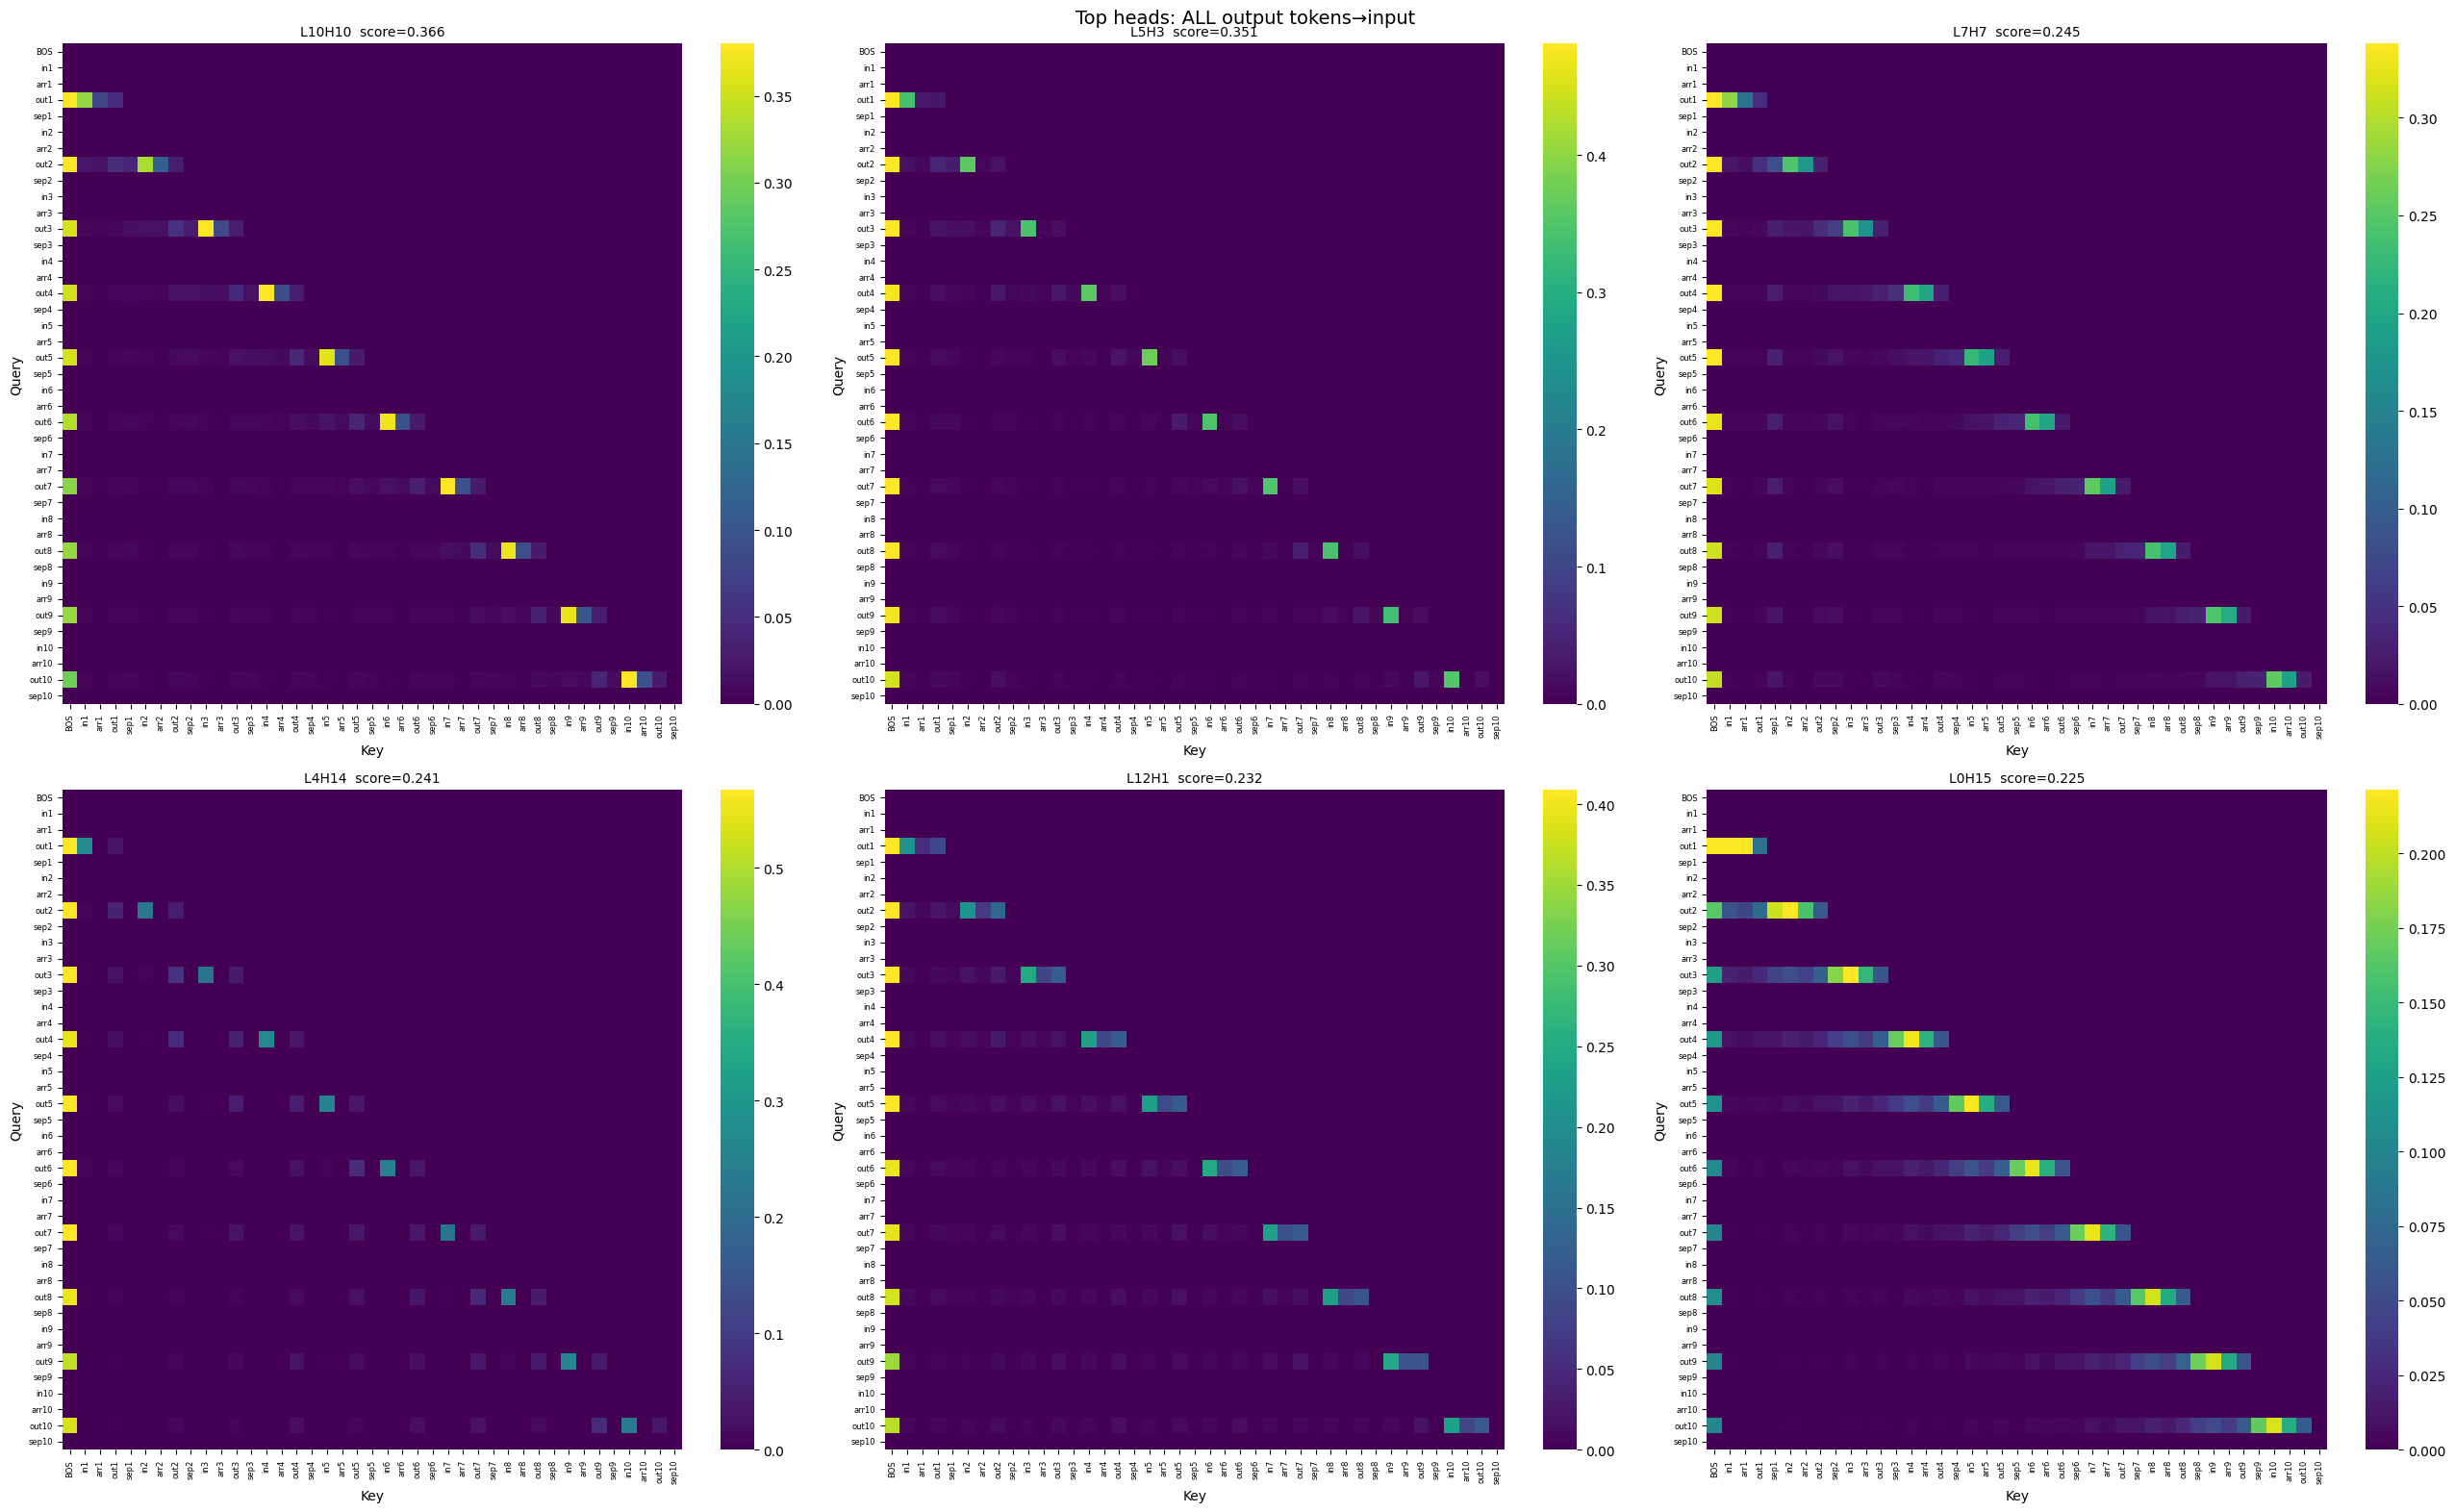

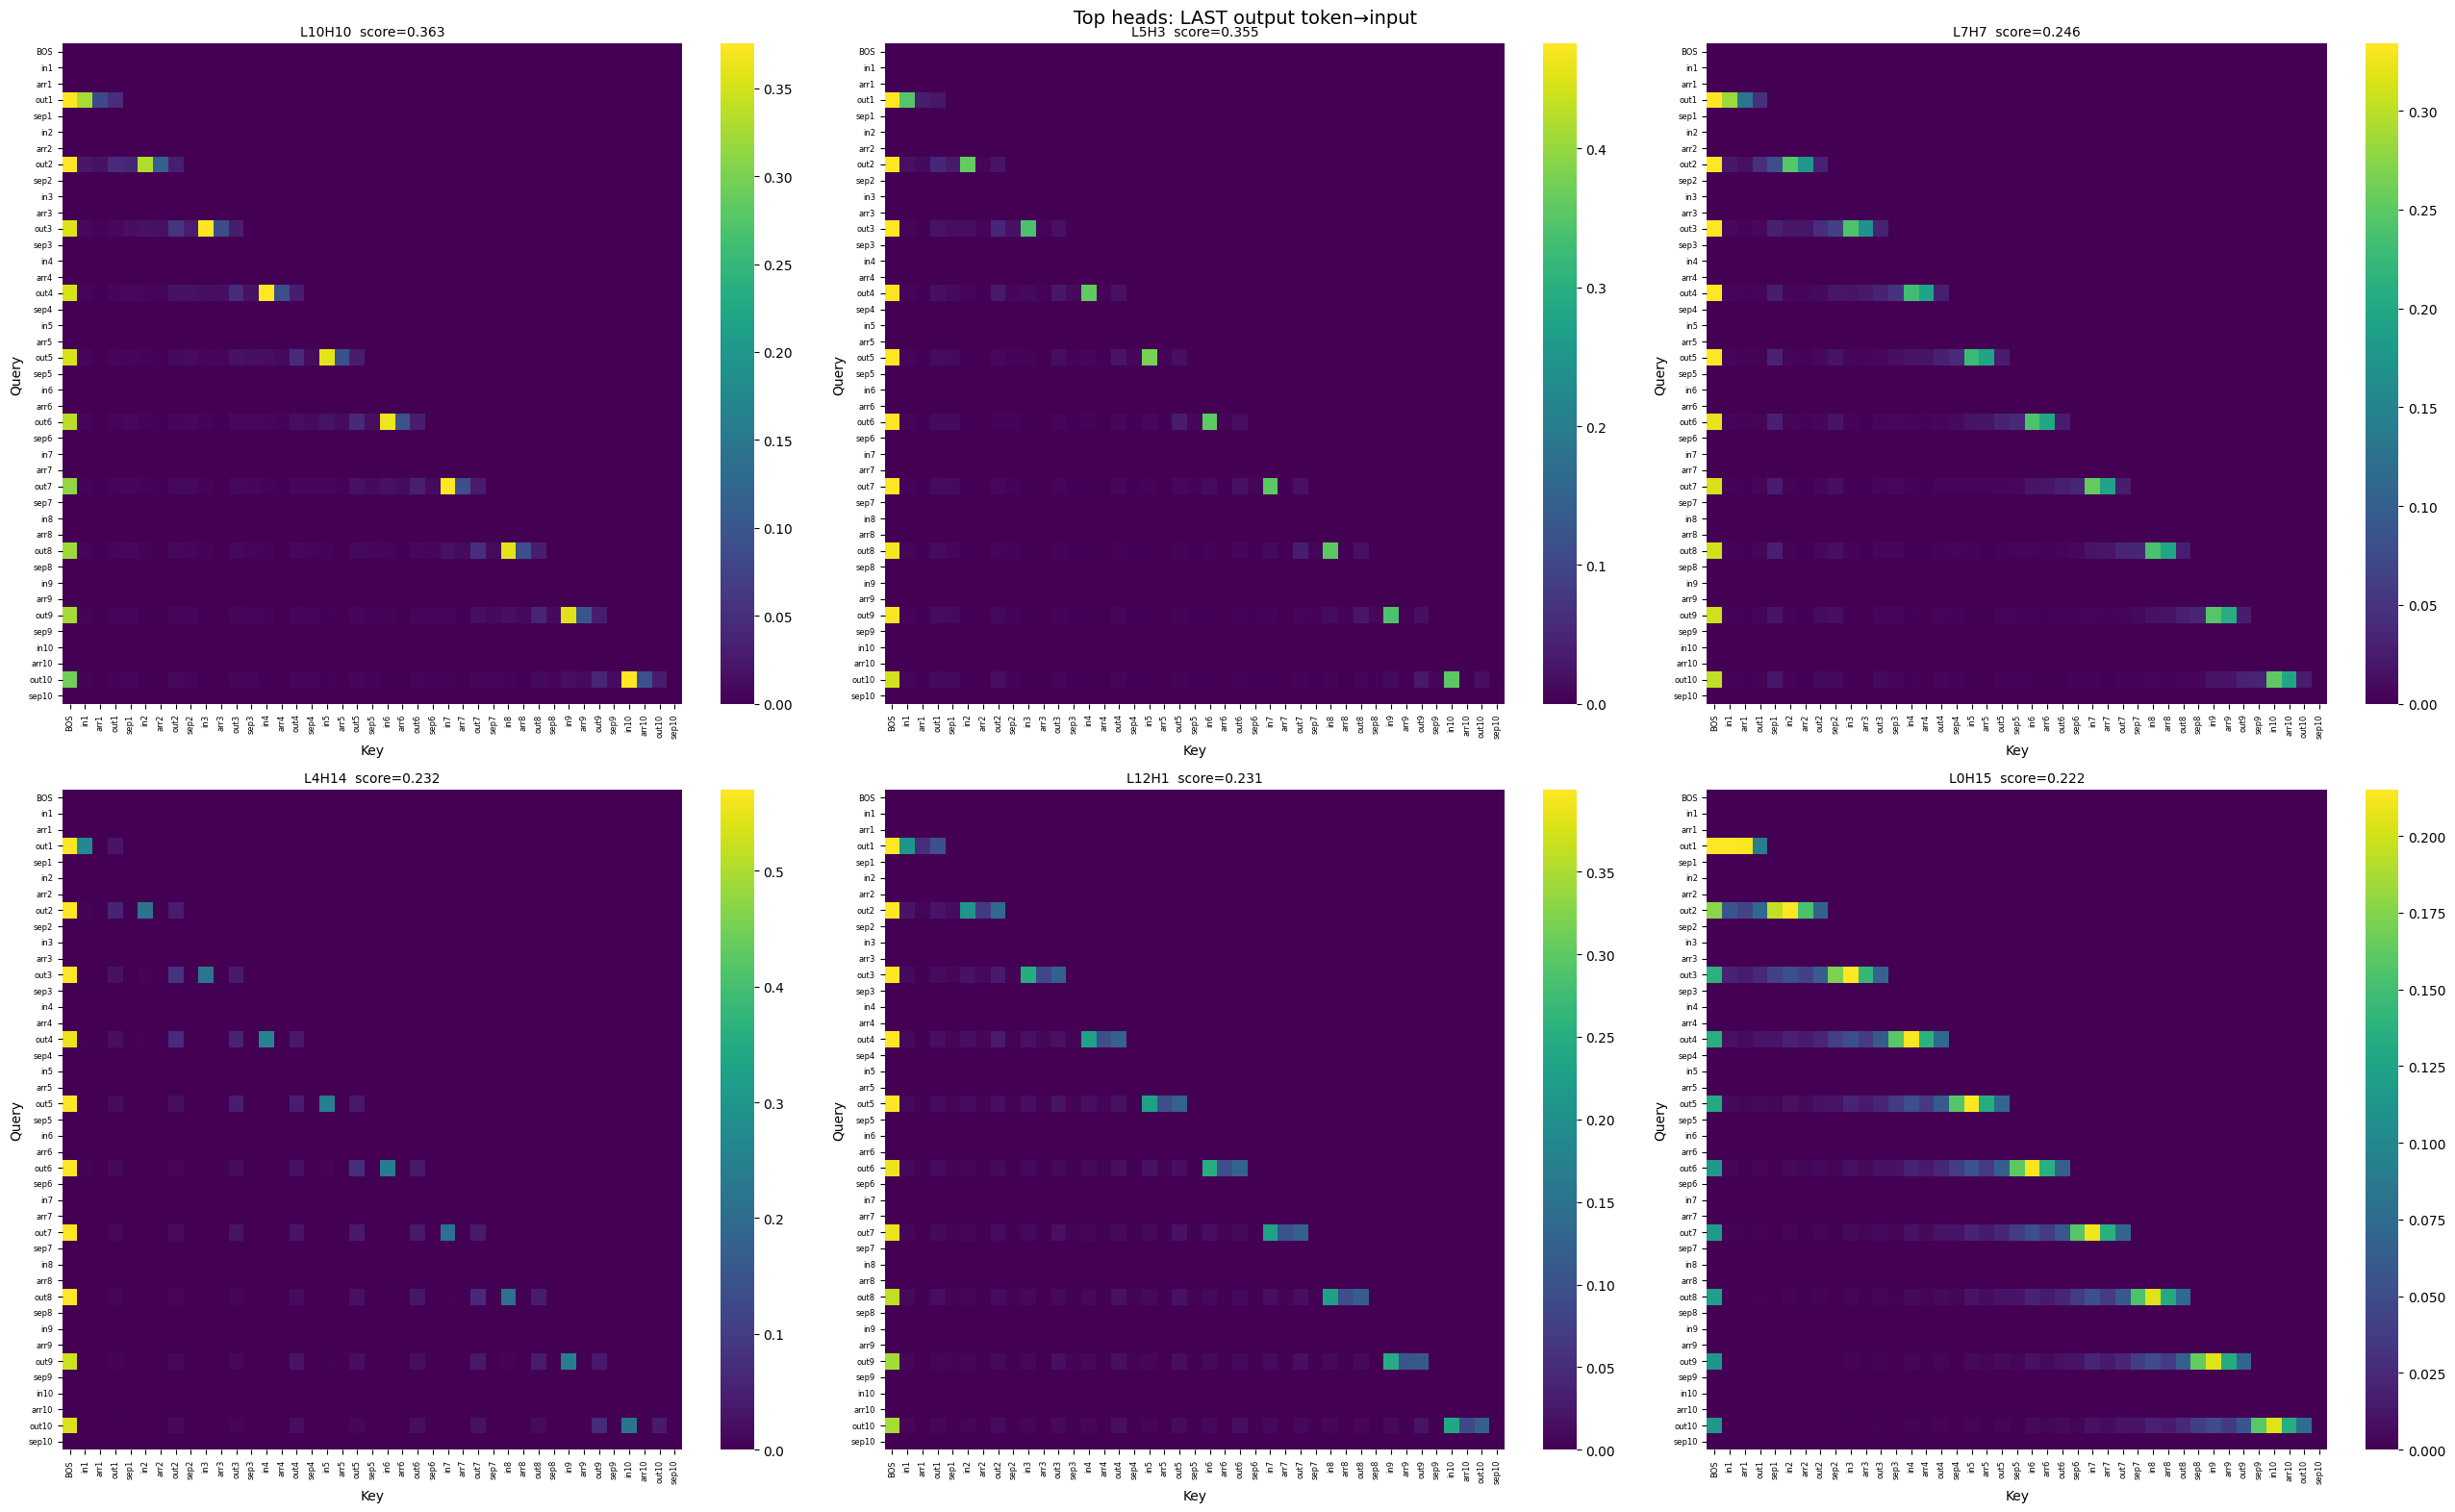

In [13]:
def plot_top(agg_dict, score, title):
    flat = sorted([(L, h, score[L, h]) for L in range(n_layers) for h in range(n_heads)], key=lambda x: -x[2])
    top = flat[:6]
    fig, axes = plt.subplots(2, 3, figsize=(26, 16))
    for ax, (L, h, sc) in zip(axes.flatten(), top):
        m = agg_dict[(L, h)]
        vmax = np.percentile(m[m > 0], 98) if (m > 0).any() else 1
        sns.heatmap(m, ax=ax, cmap='viridis', cbar=True, vmax=vmax,
                    xticklabels=ref_labels, yticklabels=ref_labels)
        ax.set_title(f'L{L}H{h}  score={sc:.3f}', fontsize=10)
        ax.set_xlabel('Key'); ax.set_ylabel('Query')
        ax.tick_params(axis='x', rotation=90, labelsize=6)
        ax.tick_params(axis='y', rotation=0, labelsize=6)
    fig.suptitle(title, fontsize=14)
    plt.tight_layout(); plt.show()

plot_top(agg_all,  score_all,  'Top heads: ALL output tokens→input')
plot_top(agg_last, score_last, 'Top heads: LAST output token→input')

## Ablation test: do these heads behave like star?

Three conditions on each prompt: original, star (inputs replaced with `*`), and original with the top output→input heads ablated *at output token positions only*. Patch the resulting residual at each layer into the zero-shot prompt and measure recovery, same as the scrambling notebook.

In [7]:
from collections import defaultdict
import random, time

PERCENTILE = 90  # top 10%
N_PROMPTS_EVAL = 10

SELECT_SCORE = score_all  # or score_last

# Top 1% by rank (robust to ties)
scores_flat = [(L, h, SELECT_SCORE[L, h]) for L in range(n_layers) for h in range(n_heads)]
scores_flat.sort(key=lambda x: -x[2])
k = max(1, int(round(len(scores_flat) * (100 - PERCENTILE) / 100)))
ABLATE_HEADS = [(L, h) for L, h, _ in scores_flat[:k]]
print(f'Ablating top {100-PERCENTILE}% = {len(ABLATE_HEADS)} heads:')
for L, h, s in scores_flat[:k]:
    print(f'  L{L}H{h}: {s:.3f}')

ablate_by_layer = defaultdict(list)
for L, h in ABLATE_HEADS:
    ablate_by_layer[L].append(h)

def make_ablation_hook(heads, output_positions_set):
    def hook_fn(z, hook):
        for h in heads:
            for p in output_positions_set:
                z[:, p, h, :] = 0
        return z
    return hook_fn

RESID_FILTER = lambda name: 'resid_post' in name
orig_per_task  = defaultdict(lambda: defaultdict(list))
star_per_task  = defaultdict(lambda: defaultdict(list))
abl_per_task   = defaultdict(lambda: defaultdict(list))

t_start = time.time()
for t_idx, (task_name, splits) in enumerate(all_splits.items()):
    eval_data = splits['eval_data']
    print(f'[{t_idx+1}/{len(all_splits)}] {task_name}')
    for p_idx, pdata in enumerate(splits['icl_prompts'][:N_PROMPTS_EVAL]):
        eq = eval_data[p_idx % len(eval_data)]
        demos = pdata['demo_pairs']
        query_input = pdata['query_input']
        
        prompt_orig = pdata['prompt']
        demos_star = [('*', out) for _, out in demos]
        prompt_star = build_icl_prompt(demos_star, query_input)
        
        tokens_orig = model.to_tokens(prompt_orig, prepend_bos=True)
        tokens_star = model.to_tokens(prompt_star, prepend_bos=True)
        
        per_demo_orig = find_per_demo_positions(model, prompt_orig, demos)
        out_positions = set()
        for d in per_demo_orig:
            out_positions.update(d.get('output_positions', []))
        
        with torch.no_grad():
            _, c_orig = model.run_with_cache(tokens_orig, names_filter=RESID_FILTER)
        with torch.no_grad():
            _, c_star = model.run_with_cache(tokens_star, names_filter=RESID_FILTER)
        hooks = [(f'blocks.{L}.attn.hook_z', make_ablation_hook(heads, out_positions))
                 for L, heads in ablate_by_layer.items()]
        with torch.no_grad(), model.hooks(fwd_hooks=hooks):
            _, c_abl = model.run_with_cache(tokens_orig, names_filter=RESID_FILTER)
        
        last_o = tokens_orig.shape[1] - 1
        last_s = tokens_star.shape[1] - 1
        
        for layer in range(n_layers):
            theta_o = c_orig['resid_post', layer][0, last_o].cpu().float().numpy()
            theta_s = c_star['resid_post', layer][0, last_s].cpu().float().numpy()
            theta_a = c_abl['resid_post',  layer][0, last_o].cpu().float().numpy()
            
            orig_per_task[task_name][layer].append(float(check_correct(model, eval_patched_resid(model, eq['zs_prompt'], theta_o, layer), eq['query_output'])))
            star_per_task[task_name][layer].append(float(check_correct(model, eval_patched_resid(model, eq['zs_prompt'], theta_s, layer), eq['query_output'])))
            abl_per_task[task_name][layer].append( float(check_correct(model, eval_patched_resid(model, eq['zs_prompt'], theta_a, layer), eq['query_output'])))
        
        del c_orig, c_star, c_abl
        torch.cuda.empty_cache()

print(f'Done in {time.time() - t_start:.0f}s')

Ablating top 10% = 67 heads:
  L10H10: 0.366
  L5H3: 0.351
  L7H7: 0.245
  L4H14: 0.241
  L12H1: 0.232
  L0H15: 0.225
  L7H18: 0.220
  L1H16: 0.218
  L13H13: 0.215
  L10H18: 0.214
  L10H7: 0.209
  L11H2: 0.208
  L5H12: 0.207
  L11H8: 0.200
  L13H9: 0.198
  L11H23: 0.198
  L10H8: 0.196
  L7H19: 0.196
  L11H11: 0.194
  L10H19: 0.194
  L11H1: 0.193
  L9H18: 0.192
  L10H13: 0.185
  L9H14: 0.184
  L6H15: 0.183
  L8H0: 0.182
  L14H7: 0.181
  L8H14: 0.178
  L10H20: 0.177
  L8H23: 0.177
  L7H20: 0.175
  L11H12: 0.175
  L7H3: 0.174
  L8H8: 0.174
  L13H12: 0.170
  L9H22: 0.170
  L7H6: 0.166
  L8H9: 0.165
  L15H22: 0.164
  L14H19: 0.164
  L13H5: 0.162
  L5H4: 0.160
  L8H22: 0.160
  L13H10: 0.159
  L12H0: 0.157
  L10H9: 0.156
  L9H0: 0.156
  L11H18: 0.156
  L8H12: 0.154
  L12H7: 0.153
  L12H6: 0.151
  L14H8: 0.151
  L13H18: 0.146
  L14H16: 0.146
  L4H6: 0.142
  L10H17: 0.141
  L12H10: 0.140
  L14H6: 0.139
  L8H1: 0.139
  L8H3: 0.137
  L9H7: 0.137
  L11H19: 0.136
  L5H17: 0.136
  L17H15: 0.135
  L7

## Aggregate plot: orig / star / head-ablated

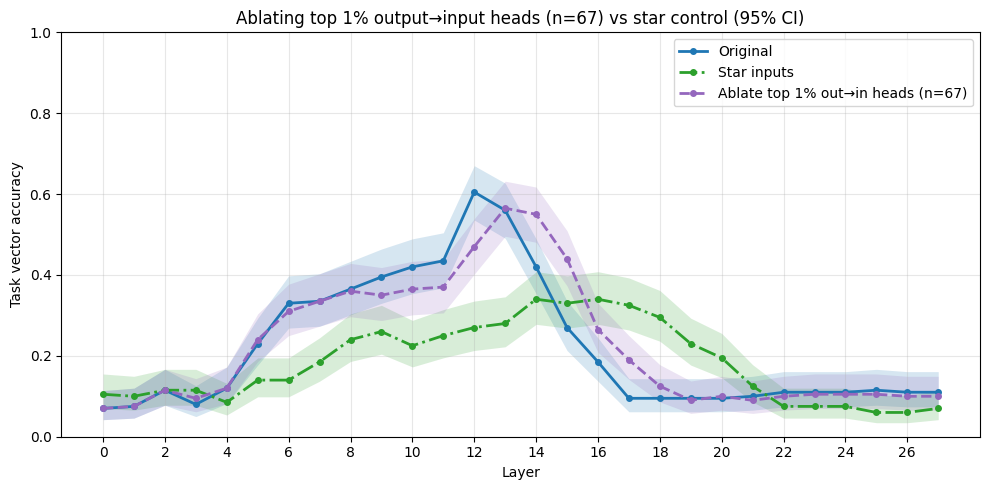

Original peak: 0.605 @ L12
Star peak:     0.340 @ L14
Ablated peak:  0.565 @ L13


In [8]:
from math import sqrt
layers = list(range(n_layers))
Z = 1.96

def ci(per_task_dict):
    means, los, his = [], [], []
    for l in layers:
        vals = [v for t in per_task_dict for v in per_task_dict[t][l]]
        n = len(vals)
        if n == 0:
            means.append(0); los.append(0); his.append(0); continue
        p = sum(vals) / n
        denom = 1 + Z**2/n
        center = (p + Z**2/(2*n)) / denom
        half = Z * sqrt(p*(1-p)/n + Z**2/(4*n**2)) / denom
        means.append(p); los.append(max(0, center-half)); his.append(min(1, center+half))
    return np.array(means), np.array(los), np.array(his)

o_m, o_lo, o_hi = ci(orig_per_task)
s_m, s_lo, s_hi = ci(star_per_task)
a_m, a_lo, a_hi = ci(abl_per_task)

fig, ax = plt.subplots(figsize=(10, 5))
for m, lo, hi, color, ls, label in [
    (o_m, o_lo, o_hi, 'tab:blue',  '-',  'Original'),
    (s_m, s_lo, s_hi, 'tab:green', '-.', 'Star inputs'),
    (a_m, a_lo, a_hi, 'tab:purple','--', f'Ablate top 1% out→in heads (n={len(ABLATE_HEADS)})'),
]:
    ax.plot(layers, m, color=color, ls=ls, lw=2, marker='o', ms=4, label=label)
    ax.fill_between(layers, lo, hi, color=color, alpha=0.18, linewidth=0)
ax.set_xlabel('Layer'); ax.set_ylabel('Task vector accuracy')
ax.set_title(f'Ablating top 1% output→input heads (n={len(ABLATE_HEADS)}) vs star control (95% CI)')
ax.set_ylim(0, 1); ax.set_xticks(range(0, n_layers, 2))
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f'Original peak: {o_m.max():.3f} @ L{int(o_m.argmax())}')
print(f'Star peak:     {s_m.max():.3f} @ L{int(s_m.argmax())}')
print(f'Ablated peak:  {a_m.max():.3f} @ L{int(a_m.argmax())}')

## Per-task summary

Sorted by orig→star drop. The ablated column should track the star column if these heads are the routing mechanism.

Task                                         Orig     Star      Abl      O-S      O-A
------------------------------------------------------------------------------------
knowledge/location_country                  0.800    0.200    0.500   +0.600   +0.300
translation/en_it                           0.700    0.100    0.800   +0.600   -0.100
translation/it_en                           0.700    0.100    0.700   +0.600   +0.000
translation/en_fr                           0.800    0.300    0.800   +0.500   +0.000
knowledge/country_capital                   0.800    0.400    0.500   +0.400   +0.300
knowledge/location_religion                 0.600    0.200    0.600   +0.400   +0.000
knowledge/person_language                   0.400    0.100    0.600   +0.300   -0.200
translation/en_es                           0.900    0.600    1.000   +0.300   -0.100
linguistic/antonyms                         0.600    0.300    0.600   +0.300   +0.000
translation/fr_en                           0.600    0.

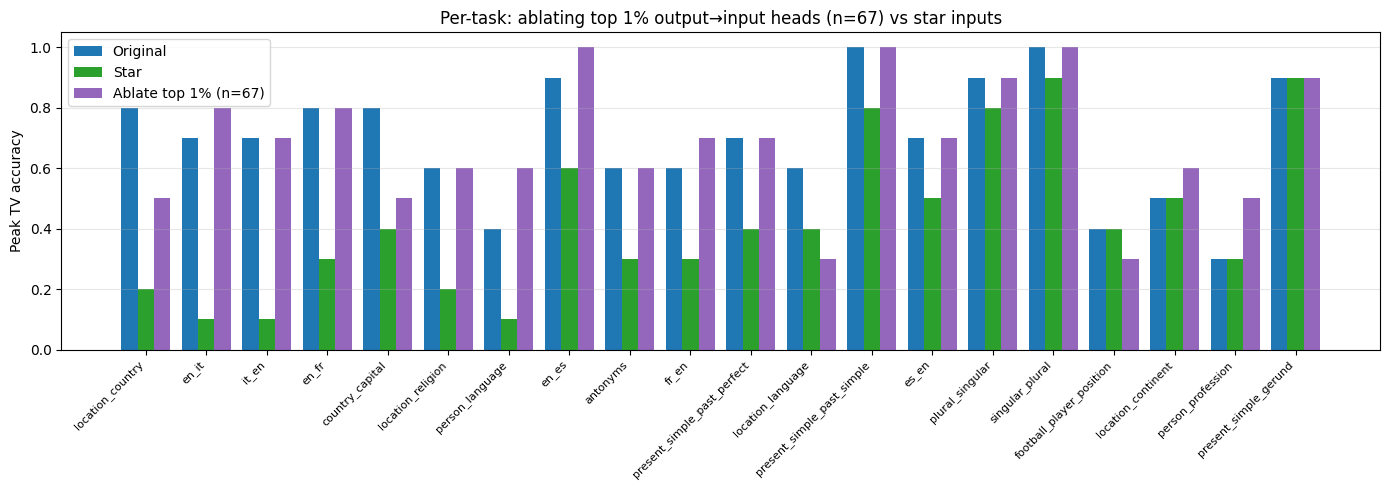

In [9]:
task_names = sorted(orig_per_task.keys())
rows = []
for t in task_names:
    o = max(np.mean(orig_per_task[t][l]) if orig_per_task[t][l] else 0 for l in layers)
    s = max(np.mean(star_per_task[t][l]) if star_per_task[t][l] else 0 for l in layers)
    a = max(np.mean(abl_per_task[t][l])  if abl_per_task[t][l]  else 0 for l in layers)
    rows.append((t, o, s, a))

print(f'{"Task":<40} {"Orig":>8} {"Star":>8} {"Abl":>8} {"O-S":>8} {"O-A":>8}')
print('-' * 84)
for t, o, s, a in sorted(rows, key=lambda r: -(r[1]-r[2])):
    print(f'{t:<40} {o:>8.3f} {s:>8.3f} {a:>8.3f} {o-s:>+8.3f} {o-a:>+8.3f}')

rows_sorted = sorted(rows, key=lambda r: -(r[1]-r[2]))
labels_short = [t.split('/')[-1] for t, *_ in rows_sorted]
x = np.arange(len(rows_sorted)); w = 0.27
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - w, [r[1] for r in rows_sorted], w, label='Original', color='tab:blue')
ax.bar(x,     [r[2] for r in rows_sorted], w, label='Star',     color='tab:green')
ax.bar(x + w, [r[3] for r in rows_sorted], w, label=f'Ablate top 1% (n={len(ABLATE_HEADS)})', color='tab:purple')
ax.set_xticks(x); ax.set_xticklabels(labels_short, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Peak TV accuracy'); ax.set_ylim(0, 1.05); ax.legend()
ax.set_title(f'Per-task: ablating top 1% output→input heads (n={len(ABLATE_HEADS)}) vs star inputs')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

## Block all output→input attention at the pattern level

Instead of ablating selected heads, mask the attention pattern at every layer so no head can attend from output positions to same-demo input positions. Renormalize so each row still sums to 1. This blocks the entire one-hop input→output routing pathway across all components in one move.

In [5]:
from collections import defaultdict
import time

N_PROMPTS_EVAL = 10

def make_block_hook(out_in_pairs):
    def hook_fn(pattern, hook):
        for q, k in out_in_pairs:
            pattern[:, :, q, k] = 0
        row_sums = pattern.sum(dim=-1, keepdim=True).clamp(min=1e-9)
        return pattern / row_sums
    return hook_fn

def out_in_pairs_for_prompt(per_demo):
    pairs = []
    for d in per_demo:
        outs = d.get('output_positions', [])
        ins = d.get('input_positions', [])
        for q in outs:
            for k in ins:
                if k < q:
                    pairs.append((q, k))
    return pairs

RESID_FILTER = lambda name: 'resid_post' in name
orig_per_task_block  = defaultdict(lambda: defaultdict(list))
star_per_task_block  = defaultdict(lambda: defaultdict(list))
block_per_task       = defaultdict(lambda: defaultdict(list))

t_start = time.time()
for t_idx, (task_name, splits) in enumerate(all_splits.items()):
    eval_data = splits['eval_data']
    print(f'[{t_idx+1}/{len(all_splits)}] {task_name}')
    for p_idx, pdata in enumerate(splits['icl_prompts'][:N_PROMPTS_EVAL]):
        eq = eval_data[p_idx % len(eval_data)]
        demos = pdata['demo_pairs']
        query_input = pdata['query_input']
        
        prompt_orig = pdata['prompt']
        demos_star = [('*', out) for _, out in demos]
        prompt_star = build_icl_prompt(demos_star, query_input)
        
        tokens_orig = model.to_tokens(prompt_orig, prepend_bos=True)
        tokens_star = model.to_tokens(prompt_star, prepend_bos=True)
        
        per_demo_orig = find_per_demo_positions(model, prompt_orig, demos)
        out_in_pairs = out_in_pairs_for_prompt(per_demo_orig)
        
        # Original
        with torch.no_grad():
            _, c_orig = model.run_with_cache(tokens_orig, names_filter=RESID_FILTER)
        # Star
        with torch.no_grad():
            _, c_star = model.run_with_cache(tokens_star, names_filter=RESID_FILTER)
        # Blocked: mask out→in attention at every layer
        block_hooks = [(f'blocks.{L}.attn.hook_pattern', make_block_hook(out_in_pairs))
                       for L in range(n_layers)]
        with torch.no_grad(), model.hooks(fwd_hooks=block_hooks):
            _, c_block = model.run_with_cache(tokens_orig, names_filter=RESID_FILTER)
        
        last_o = tokens_orig.shape[1] - 1
        last_s = tokens_star.shape[1] - 1
        
        for layer in range(n_layers):
            theta_o = c_orig['resid_post', layer][0, last_o].cpu().float().numpy()
            theta_s = c_star['resid_post', layer][0, last_s].cpu().float().numpy()
            theta_b = c_block['resid_post', layer][0, last_o].cpu().float().numpy()
            
            orig_per_task_block[task_name][layer].append(float(check_correct(model, eval_patched_resid(model, eq['zs_prompt'], theta_o, layer), eq['query_output'])))
            star_per_task_block[task_name][layer].append(float(check_correct(model, eval_patched_resid(model, eq['zs_prompt'], theta_s, layer), eq['query_output'])))
            block_per_task[task_name][layer].append(    float(check_correct(model, eval_patched_resid(model, eq['zs_prompt'], theta_b, layer), eq['query_output'])))
        
        del c_orig, c_star, c_block
        torch.cuda.empty_cache()

print(f'Done in {time.time() - t_start:.0f}s')

[1/20] knowledge/country_capital
[2/20] knowledge/football_player_position
[3/20] knowledge/location_continent
[4/20] knowledge/location_country
[5/20] knowledge/location_language
[6/20] knowledge/location_religion
[7/20] knowledge/person_language
[8/20] knowledge/person_profession
[9/20] linguistic/antonyms
[10/20] linguistic/plural_singular
[11/20] linguistic/present_simple_gerund
[12/20] linguistic/present_simple_past_perfect
[13/20] linguistic/present_simple_past_simple
[14/20] linguistic/singular_plural
[15/20] translation/en_es
[16/20] translation/en_fr
[17/20] translation/en_it
[18/20] translation/es_en
[19/20] translation/fr_en
[20/20] translation/it_en
Done in 704s


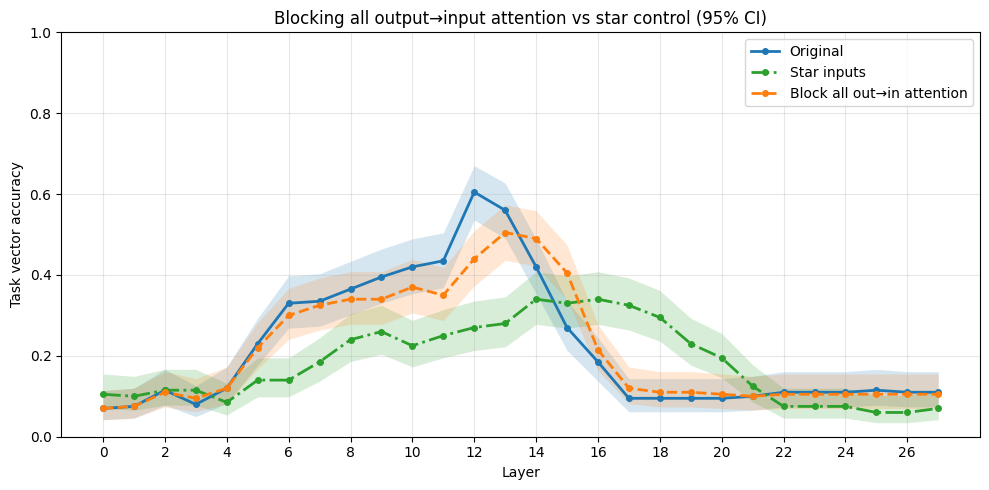

Original peak: 0.605 @ L12
Star peak:     0.340 @ L14
Blocked peak:  0.505 @ L13

Task                                         Orig     Star  Blocked      O-S      O-B
------------------------------------------------------------------------------------
knowledge/location_country                  0.800    0.200    0.300   +0.600   +0.500
translation/en_it                           0.700    0.100    0.500   +0.600   +0.200
translation/it_en                           0.700    0.100    0.600   +0.600   +0.100
translation/en_fr                           0.800    0.300    0.600   +0.500   +0.200
knowledge/country_capital                   0.800    0.400    0.300   +0.400   +0.500
knowledge/location_religion                 0.600    0.200    0.600   +0.400   +0.000
knowledge/person_language                   0.400    0.100    0.600   +0.300   -0.200
translation/en_es                           0.900    0.600    0.900   +0.300   +0.000
linguistic/antonyms                         0.600    0.300 

In [8]:
from math import sqrt

layers = list(range(n_layers))
Z = 1.96

def ci(per_task_dict):
    means, los, his = [], [], []
    for l in layers:
        vals = [v for t in per_task_dict for v in per_task_dict[t][l]]
        n = len(vals)
        if n == 0:
            means.append(0); los.append(0); his.append(0); continue
        p = sum(vals) / n
        denom = 1 + Z**2/n
        center = (p + Z**2/(2*n)) / denom
        half = Z * sqrt(p*(1-p)/n + Z**2/(4*n**2)) / denom
        means.append(p); los.append(max(0, center-half)); his.append(min(1, center+half))
    return np.array(means), np.array(los), np.array(his)

o_m, o_lo, o_hi = ci(orig_per_task_block)
s_m, s_lo, s_hi = ci(star_per_task_block)
b_m, b_lo, b_hi = ci(block_per_task)

fig, ax = plt.subplots(figsize=(10, 5))
for m, lo, hi, color, ls, label in [
    (o_m, o_lo, o_hi, 'tab:blue',   '-',  'Original'),
    (s_m, s_lo, s_hi, 'tab:green',  '-.', 'Star inputs'),
    (b_m, b_lo, b_hi, 'tab:orange', '--', 'Block all out→in attention'),
]:
    ax.plot(layers, m, color=color, ls=ls, lw=2, marker='o', ms=4, label=label)
    ax.fill_between(layers, lo, hi, color=color, alpha=0.18, linewidth=0)
ax.set_xlabel('Layer'); ax.set_ylabel('Task vector accuracy')
ax.set_title('Blocking all output→input attention vs star control (95% CI)')
ax.set_ylim(0, 1); ax.set_xticks(range(0, n_layers, 2))
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f'Original peak: {o_m.max():.3f} @ L{int(o_m.argmax())}')
print(f'Star peak:     {s_m.max():.3f} @ L{int(s_m.argmax())}')
print(f'Blocked peak:  {b_m.max():.3f} @ L{int(b_m.argmax())}')

# Per-task
task_names = sorted(orig_per_task_block.keys())
rows = []
for t in task_names:
    o = max(np.mean(orig_per_task_block[t][l]) if orig_per_task_block[t][l] else 0 for l in layers)
    s = max(np.mean(star_per_task_block[t][l]) if star_per_task_block[t][l] else 0 for l in layers)
    b = max(np.mean(block_per_task[t][l]) if block_per_task[t][l] else 0 for l in layers)
    rows.append((t, o, s, b))

print(f'\n{"Task":<40} {"Orig":>8} {"Star":>8} {"Blocked":>8} {"O-S":>8} {"O-B":>8}')
print('-' * 84)
for t, o, s, b in sorted(rows, key=lambda r: -(r[1]-r[2])):
    print(f'{t:<40} {o:>8.3f} {s:>8.3f} {b:>8.3f} {o-s:>+8.3f} {o-b:>+8.3f}')

In [9]:
from collections import defaultdict
import time

def first_tok_id(word, model):
    return model.to_tokens(' ' + word, prepend_bos=False)[0][0].item()

NAMES = lambda name: 'resid_pre' in name

orig_ranks = defaultdict(list)  # layer -> [rank per prompt]
star_ranks = defaultdict(list)

t_start = time.time()
for t_idx, (task_name, splits) in enumerate(all_splits.items()):
    print(f'[{t_idx+1}/{len(all_splits)}] {task_name}')
    eval_data = splits['eval_data']
    for p_idx, pdata in enumerate(splits['icl_prompts'][:10]):
        eq = eval_data[p_idx % len(eval_data)]
        demos = pdata['demo_pairs']
        query_input = pdata['query_input']
        correct = eq['query_output']
        ans_tok = first_tok_id(correct, model)
        
        # Original
        prompt_orig = pdata['prompt']
        tokens_orig = model.to_tokens(prompt_orig, prepend_bos=True)
        last_o = tokens_orig.shape[1] - 1
        with torch.no_grad():
            _, c_orig = model.run_with_cache(tokens_orig, names_filter=NAMES)
        
        # Star
        demos_star = [('*', out) for _, out in demos]
        prompt_star = build_icl_prompt(demos_star, query_input)
        tokens_star = model.to_tokens(prompt_star, prepend_bos=True)
        last_s = tokens_star.shape[1] - 1
        with torch.no_grad():
            _, c_star = model.run_with_cache(tokens_star, names_filter=NAMES)
        
        for L in range(n_layers):
            # Use resid_pre of layer L+1 ≈ post-everything of layer L
            target = L + 1 if L + 1 < n_layers else L
            r_o = c_orig[f'blocks.{target}.hook_resid_pre'][0, last_o]
            r_s = c_star[f'blocks.{target}.hook_resid_pre'][0, last_s]
            
            with torch.no_grad():
                normed_o = model.ln_final(r_o.unsqueeze(0))
                logits_o = (normed_o @ model.W_U).squeeze().cpu().float().numpy()
                normed_s = model.ln_final(r_s.unsqueeze(0))
                logits_s = (normed_s @ model.W_U).squeeze().cpu().float().numpy()
            
            orig_ranks[L].append((logits_o > logits_o[ans_tok]).sum())
            star_ranks[L].append((logits_s > logits_s[ans_tok]).sum())
        
        del c_orig, c_star
        torch.cuda.empty_cache()

print(f'Done in {time.time() - t_start:.0f}s')

[1/20] knowledge/country_capital
[2/20] knowledge/football_player_position
[3/20] knowledge/location_continent
[4/20] knowledge/location_country
[5/20] knowledge/location_language
[6/20] knowledge/location_religion
[7/20] knowledge/person_language
[8/20] knowledge/person_profession
[9/20] linguistic/antonyms
[10/20] linguistic/plural_singular
[11/20] linguistic/present_simple_gerund
[12/20] linguistic/present_simple_past_perfect
[13/20] linguistic/present_simple_past_simple
[14/20] linguistic/singular_plural
[15/20] translation/en_es
[16/20] translation/en_fr
[17/20] translation/en_it
[18/20] translation/es_en
[19/20] translation/fr_en
[20/20] translation/it_en
Done in 33s


## Rank trajectory

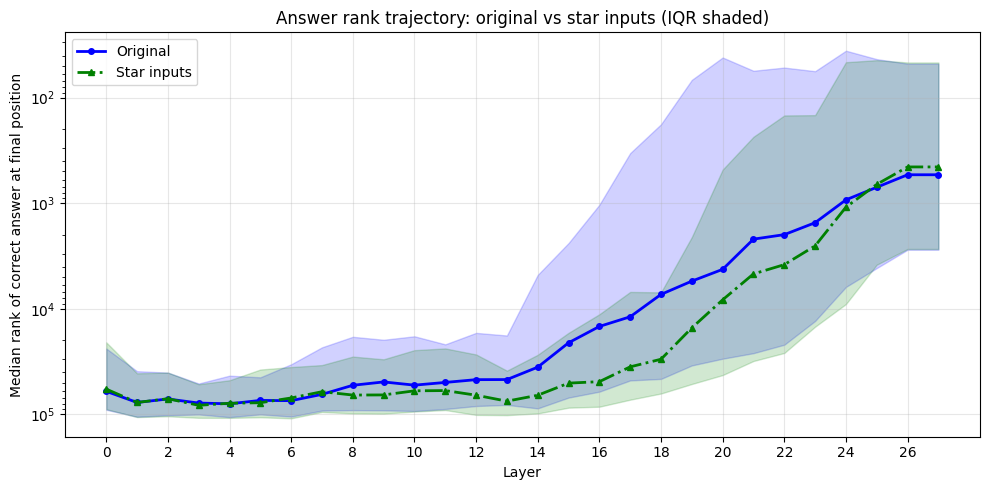


 Layer    Orig median    Star median  Star/Orig
------------------------------------------------
     0          60606          57756       0.95
     4          79532          78584       0.99
     8          53120          65720       1.24
    12          46980          65939       1.40
    14          35780          66031       1.85
    16          14721          49082       3.33
    20           4238           8237       1.94
    24            930           1092       1.17
    27            538            454       0.84


In [10]:
# Plot: median rank trajectory with IQR shading

layers = list(range(n_layers))
o_med  = [np.median(orig_ranks[l]) for l in layers]
o_q25  = [np.percentile(orig_ranks[l], 25) for l in layers]
o_q75  = [np.percentile(orig_ranks[l], 75) for l in layers]
s_med  = [np.median(star_ranks[l]) for l in layers]
s_q25  = [np.percentile(star_ranks[l], 25) for l in layers]
s_q75  = [np.percentile(star_ranks[l], 75) for l in layers]

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogy(layers, o_med, 'b-o', ms=4, lw=2, label='Original')
ax.fill_between(layers, o_q25, o_q75, color='blue', alpha=0.18)
ax.semilogy(layers, s_med, 'g-.^', ms=4, lw=2, label='Star inputs')
ax.fill_between(layers, s_q25, s_q75, color='green', alpha=0.18)
ax.invert_yaxis()
ax.set_xlabel('Layer')
ax.set_ylabel('Median rank of correct answer at final position')
ax.set_title('Answer rank trajectory: original vs star inputs (IQR shaded)')
ax.set_xticks(range(0, n_layers, 2))
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f'\n{"Layer":>6} {"Orig median":>14} {"Star median":>14} {"Star/Orig":>10}')
print('-' * 48)
for L in [0, 4, 8, 12, 14, 16, 20, 24, 27]:
    om, sm = np.median(orig_ranks[L]), np.median(star_ranks[L])
    print(f'{L:>6} {om:>14.0f} {sm:>14.0f} {sm/max(om,1):>10.2f}')

## ICL accuracy

In [17]:
from collections import defaultdict
import time

tasks = load_hendel_data(HENDEL_REPO)

# Heads to ablate (top 10% by output→input score) — reuses score_all from earlier
PERCENTILE = 90
scores_flat = [(L, h, score_all[L, h]) for L in range(n_layers) for h in range(n_heads)]
scores_flat.sort(key=lambda x: -x[2])
k = max(1, int(round(len(scores_flat) * (100 - PERCENTILE) / 100)))
ABLATE_HEADS = [(L, h) for L, h, _ in scores_flat[:k]]
ablate_by_layer = defaultdict(list)
for L, h in ABLATE_HEADS:
    ablate_by_layer[L].append(h)
print(f'Ablating {len(ABLATE_HEADS)} heads (top {100-PERCENTILE}%)')

def make_head_ablation_hook(heads, output_positions_set):
    def hook_fn(z, hook):
        for h in heads:
            for p in output_positions_set:
                z[:, p, h, :] = 0
        return z
    return hook_fn

def make_block_attn_hook(out_in_pairs):
    def hook_fn(pattern, hook):
        for q, k in out_in_pairs:
            pattern[:, :, q, k] = 0
        row_sums = pattern.sum(dim=-1, keepdim=True).clamp(min=1e-9)
        return pattern / row_sums
    return hook_fn

icl_orig    = defaultdict(int)
icl_star    = defaultdict(int)
icl_ablate  = defaultdict(int)
icl_block   = defaultdict(int)
icl_n       = defaultdict(int)

t_start = time.time()
for t_idx, (task_name, splits) in enumerate(all_splits.items()):
    print(f'[{t_idx+1}/{len(all_splits)}] {task_name}')
    task_pairs_dict = dict(tasks[task_name])
    
    for pdata in splits['icl_prompts'][:10]:
        demos = pdata['demo_pairs']
        query_input = pdata['query_input']
        correct_answer = pdata.get('query_output') or task_pairs_dict.get(query_input)
        if correct_answer is None:
            continue
        
        # Build the two prompts
        prompt_orig = pdata['prompt']
        prompt_star = build_icl_prompt([('*', out) for _, out in demos], query_input)
        
        tokens_orig = model.to_tokens(prompt_orig, prepend_bos=True)
        tokens_star = model.to_tokens(prompt_star, prepend_bos=True)
        last_o = tokens_orig.shape[1] - 1
        last_s = tokens_star.shape[1] - 1
        
        # Find positions for the two interventions on the original prompt
        per_demo_orig = find_per_demo_positions(model, prompt_orig, demos)
        out_positions = set()
        for d in per_demo_orig:
            out_positions.update(d.get('output_positions', []))
        out_in_pairs = []
        for d in per_demo_orig:
            outs = d.get('output_positions', [])
            ins  = d.get('input_positions', [])
            for q in outs:
                for kk in ins:
                    if kk < q:
                        out_in_pairs.append((q, kk))
        
        # 1. Original ICL
        with torch.no_grad():
            logits = model(tokens_orig)[0, last_o]
        icl_orig[task_name] += int(check_correct(model, logits, correct_answer))
        
        # 2. Star inputs
        with torch.no_grad():
            logits = model(tokens_star)[0, last_s]
        icl_star[task_name] += int(check_correct(model, logits, correct_answer))
        
        # 3. Head ablation at output positions
        head_hooks = [(f'blocks.{L}.attn.hook_z', make_head_ablation_hook(heads, out_positions))
                      for L, heads in ablate_by_layer.items()]
        with torch.no_grad(), model.hooks(fwd_hooks=head_hooks):
            logits = model(tokens_orig)[0, last_o]
        icl_ablate[task_name] += int(check_correct(model, logits, correct_answer))
        
        # 4. Attention knockout out→in at every layer
        block_hooks = [(f'blocks.{L}.attn.hook_pattern', make_block_attn_hook(out_in_pairs))
                       for L in range(n_layers)]
        with torch.no_grad(), model.hooks(fwd_hooks=block_hooks):
            logits = model(tokens_orig)[0, last_o]
        icl_block[task_name] += int(check_correct(model, logits, correct_answer))
        
        icl_n[task_name] += 1
        torch.cuda.empty_cache()

print(f'Done in {time.time() - t_start:.0f}s')

Ablating 67 heads (top 10%)
[1/20] knowledge/country_capital
[2/20] knowledge/football_player_position
[3/20] knowledge/location_continent
[4/20] knowledge/location_country
[5/20] knowledge/location_language
[6/20] knowledge/location_religion
[7/20] knowledge/person_language
[8/20] knowledge/person_profession
[9/20] linguistic/antonyms
[10/20] linguistic/plural_singular
[11/20] linguistic/present_simple_gerund
[12/20] linguistic/present_simple_past_perfect
[13/20] linguistic/present_simple_past_simple
[14/20] linguistic/singular_plural
[15/20] translation/en_es
[16/20] translation/en_fr
[17/20] translation/en_it
[18/20] translation/es_en
[19/20] translation/fr_en
[20/20] translation/it_en
Done in 37s



=== Aggregate ICL accuracy (n=200) ===
  Original                         0.835  [0.777, 0.880]
  Star inputs                      0.330  [0.269, 0.398]
  Head ablation (top 10%)          0.795  [0.734, 0.845]
  Attention knockout out→in        0.750  [0.686, 0.805]

Task                                         Orig     Star    HeadAbl   BlockAttn
--------------------------------------------------------------------------------
linguistic/present_simple_gerund             1.00     0.10       1.00        0.90
knowledge/location_religion                  1.00     0.30       0.90        1.00
linguistic/antonyms                          1.00     0.30       0.90        0.60
linguistic/plural_singular                   1.00     0.30       1.00        0.80
linguistic/present_simple_past_perfect       1.00     0.30       0.70        0.70
translation/it_en                            0.90     0.20       0.80        0.80
translation/en_it                            0.90     0.30       0.80       

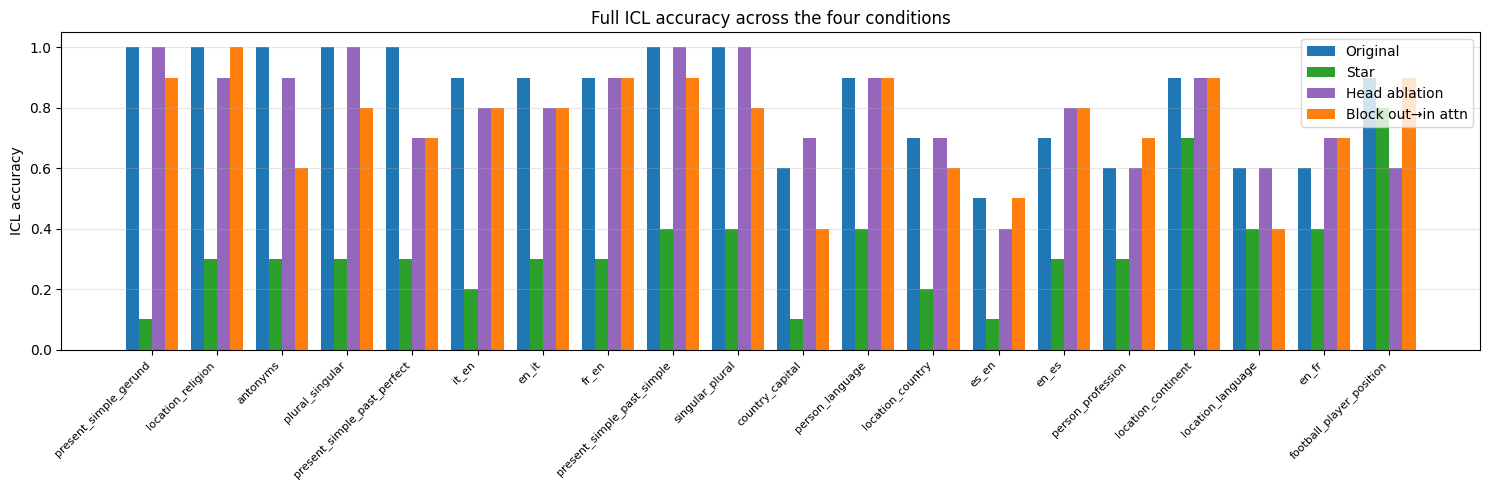

In [18]:
# Aggregate + per-task results
from math import sqrt
Z = 1.96

def wilson(k, n):
    if n == 0: return 0, 0, 0
    p = k / n
    denom = 1 + Z**2/n
    center = (p + Z**2/(2*n)) / denom
    half = Z * sqrt(p*(1-p)/n + Z**2/(4*n**2)) / denom
    return p, max(0, center-half), min(1, center+half)

# Aggregate across tasks
total_n = sum(icl_n.values())
agg_orig   = sum(icl_orig.values()) / total_n
agg_star   = sum(icl_star.values()) / total_n
agg_ablate = sum(icl_ablate.values()) / total_n
agg_block  = sum(icl_block.values()) / total_n

print(f'\n=== Aggregate ICL accuracy (n={total_n}) ===')
for label, k in [('Original', sum(icl_orig.values())),
                 ('Star inputs', sum(icl_star.values())),
                 ('Head ablation (top 10%)', sum(icl_ablate.values())),
                 ('Attention knockout out→in', sum(icl_block.values()))]:
    p, lo, hi = wilson(k, total_n)
    print(f'  {label:<32} {p:.3f}  [{lo:.3f}, {hi:.3f}]')

# Per-task table sorted by orig→star drop
print(f'\n{"Task":<40} {"Orig":>8} {"Star":>8} {"HeadAbl":>10} {"BlockAttn":>11}')
print('-' * 80)
rows = [(t, icl_orig[t]/icl_n[t], icl_star[t]/icl_n[t], icl_ablate[t]/icl_n[t], icl_block[t]/icl_n[t])
        for t in sorted(icl_n.keys())]
for t, o, s, a, b in sorted(rows, key=lambda r: -(r[1]-r[2])):
    print(f'{t:<40} {o:>8.2f} {s:>8.2f} {a:>10.2f} {b:>11.2f}')

# Bar plot
import matplotlib.pyplot as plt
labels_short = [t.split('/')[-1] for t, *_ in sorted(rows, key=lambda r: -(r[1]-r[2]))]
rows_sorted = sorted(rows, key=lambda r: -(r[1]-r[2]))
x = np.arange(len(rows_sorted)); w = 0.2
fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(x - 1.5*w, [r[1] for r in rows_sorted], w, label='Original', color='tab:blue')
ax.bar(x - 0.5*w, [r[2] for r in rows_sorted], w, label='Star', color='tab:green')
ax.bar(x + 0.5*w, [r[3] for r in rows_sorted], w, label='Head ablation', color='tab:purple')
ax.bar(x + 1.5*w, [r[4] for r in rows_sorted], w, label='Block out→in attn', color='tab:orange')
ax.set_xticks(x); ax.set_xticklabels(labels_short, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('ICL accuracy'); ax.set_ylim(0, 1.05); ax.legend()
ax.set_title('Full ICL accuracy across the four conditions')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

## Arrow-attending heads

In [19]:
# ============================================================
# Score: output → same-demo arrow
# ============================================================

PATTERN_FILTER = lambda name: 'attn.hook_pattern' in name

# Reuse build_slot_map and aggregate_attn from earlier in the notebook
agg_arrow_all_sum  = {(L, h): None for L in range(n_layers) for h in range(n_heads)}
agg_arrow_last_sum = {(L, h): None for L in range(n_layers) for h in range(n_heads)}
counts = 0
ref_labels = None

for task_name, splits in tqdm(all_splits.items()):
    for pdata in splits['icl_prompts'][:5]:
        tokens = model.to_tokens(pdata['prompt'], prepend_bos=True)
        seq_len = tokens.shape[1]
        per_demo = find_per_demo_positions(model, pdata['prompt'], pdata['demo_pairs'])
        if len(per_demo) != N_DEMOS: continue
        
        slot_of, labels = build_slot_map(seq_len, per_demo, N_DEMOS)
        if slot_of is None: continue
        if ref_labels is None: ref_labels = labels
        if len(labels) != len(ref_labels): continue
        
        all_out_q  = set(p for d in per_demo for p in d.get('output_positions', []))
        last_out_q = set(max(d.get('output_positions', [0])) for d in per_demo if d.get('output_positions', []))
        
        with torch.no_grad():
            _, cache = model.run_with_cache(tokens, names_filter=PATTERN_FILTER)
        for L in range(n_layers):
            patt = cache[f'blocks.{L}.attn.hook_pattern'][0].cpu().float().numpy()
            for h in range(n_heads):
                m_all  = aggregate_attn(patt[h], slot_of, len(labels), all_out_q)
                m_last = aggregate_attn(patt[h], slot_of, len(labels), last_out_q)
                if agg_arrow_all_sum[(L, h)] is None:
                    agg_arrow_all_sum[(L, h)]  = m_all
                    agg_arrow_last_sum[(L, h)] = m_last
                else:
                    agg_arrow_all_sum[(L, h)]  += m_all
                    agg_arrow_last_sum[(L, h)] += m_last
        counts += 1
        del cache; torch.cuda.empty_cache()

agg_arrow_all  = {k: v / counts for k, v in agg_arrow_all_sum.items()}
agg_arrow_last = {k: v / counts for k, v in agg_arrow_last_sum.items()}
print(f'{counts} prompts, {len(ref_labels)} slots')

100%|██████████| 20/20 [00:24<00:00,  1.23s/it]

100 prompts, 41 slots


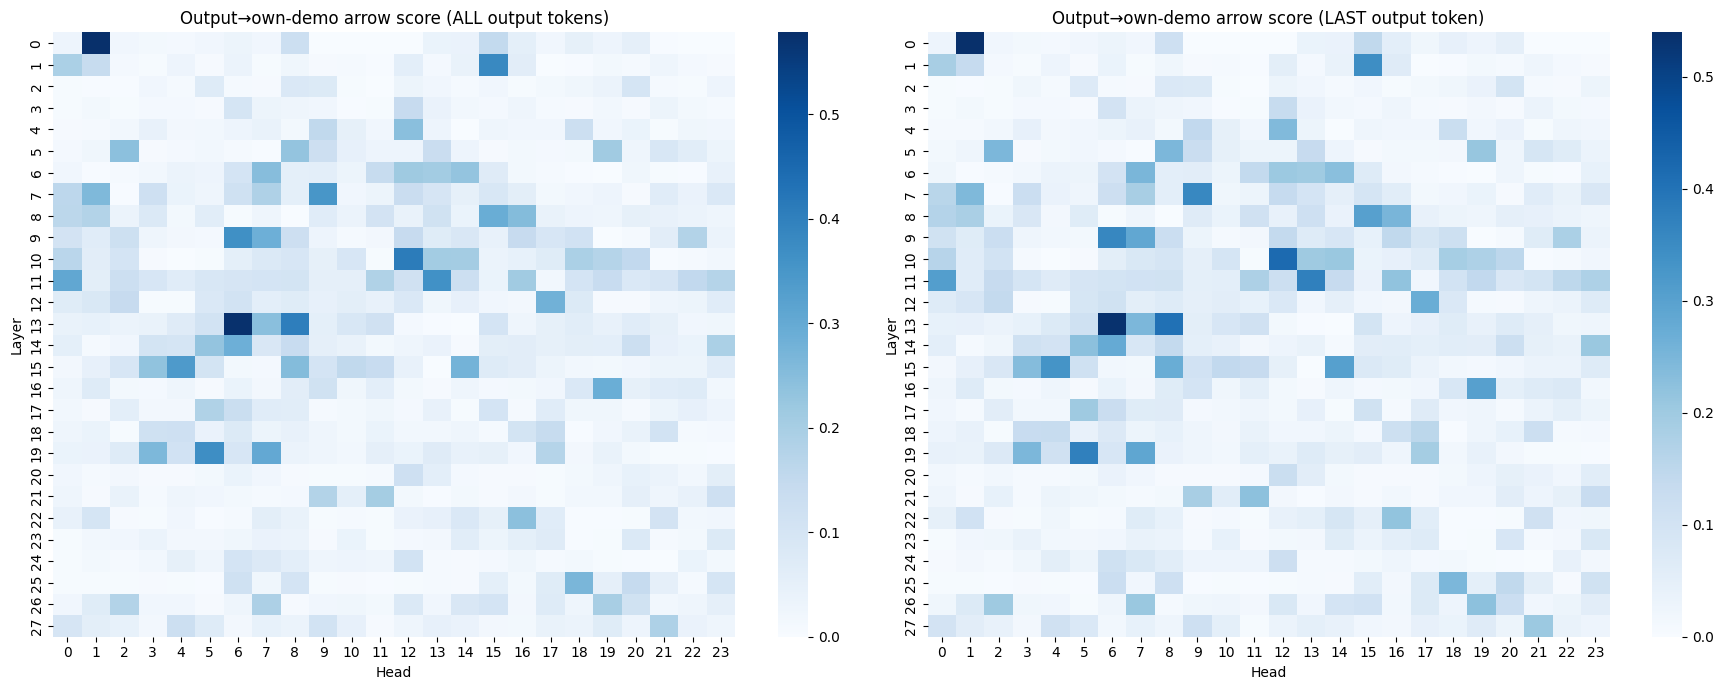


Top 10 (ALL):
  L0H1: 0.578
  L13H6: 0.574
  L10H12: 0.410
  L13H8: 0.405
  L1H15: 0.381
  L19H5: 0.370
  L9H6: 0.364
  L11H13: 0.362
  L7H9: 0.352
  L15H4: 0.340

Top 10 (LAST):
  L0H1: 0.539
  L13H6: 0.535
  L10H12: 0.417
  L13H8: 0.403
  L19H5: 0.375
  L11H13: 0.374
  L9H6: 0.360
  L7H9: 0.357
  L1H15: 0.344
  L15H4: 0.333


In [20]:
# ============================================================
# Scores: own-demo arrow, and previous-token (output → arrow_d, where arr_d is the prev token)
# ============================================================

def own_arrow_score(agg_dict, labels):
    out_slots = [i for i, l in enumerate(labels) if l.startswith('out')]
    arr_slots = [i for i, l in enumerate(labels) if l.startswith('arr')]
    score = np.zeros((n_layers, n_heads))
    for (L, h), m in agg_dict.items():
        score[L, h] = sum(m[o, a] for o, a in zip(out_slots, arr_slots)) / len(out_slots)
    return score

score_arrow_all  = own_arrow_score(agg_arrow_all,  ref_labels)
score_arrow_last = own_arrow_score(agg_arrow_last, ref_labels)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, sc, title in zip(axes, [score_arrow_all, score_arrow_last], ['ALL output tokens', 'LAST output token']):
    sns.heatmap(sc, ax=ax, cmap='Blues', vmin=0)
    ax.set_title(f'Output→own-demo arrow score ({title})')
    ax.set_xlabel('Head'); ax.set_ylabel('Layer')
plt.tight_layout(); plt.show()

for label, sc in [('ALL', score_arrow_all), ('LAST', score_arrow_last)]:
    flat = sorted([(L, h, sc[L, h]) for L in range(n_layers) for h in range(n_heads)], key=lambda x: -x[2])
    print(f'\nTop 10 ({label}):')
    for L, h, s in flat[:10]:
        print(f'  L{L}H{h}: {s:.3f}')

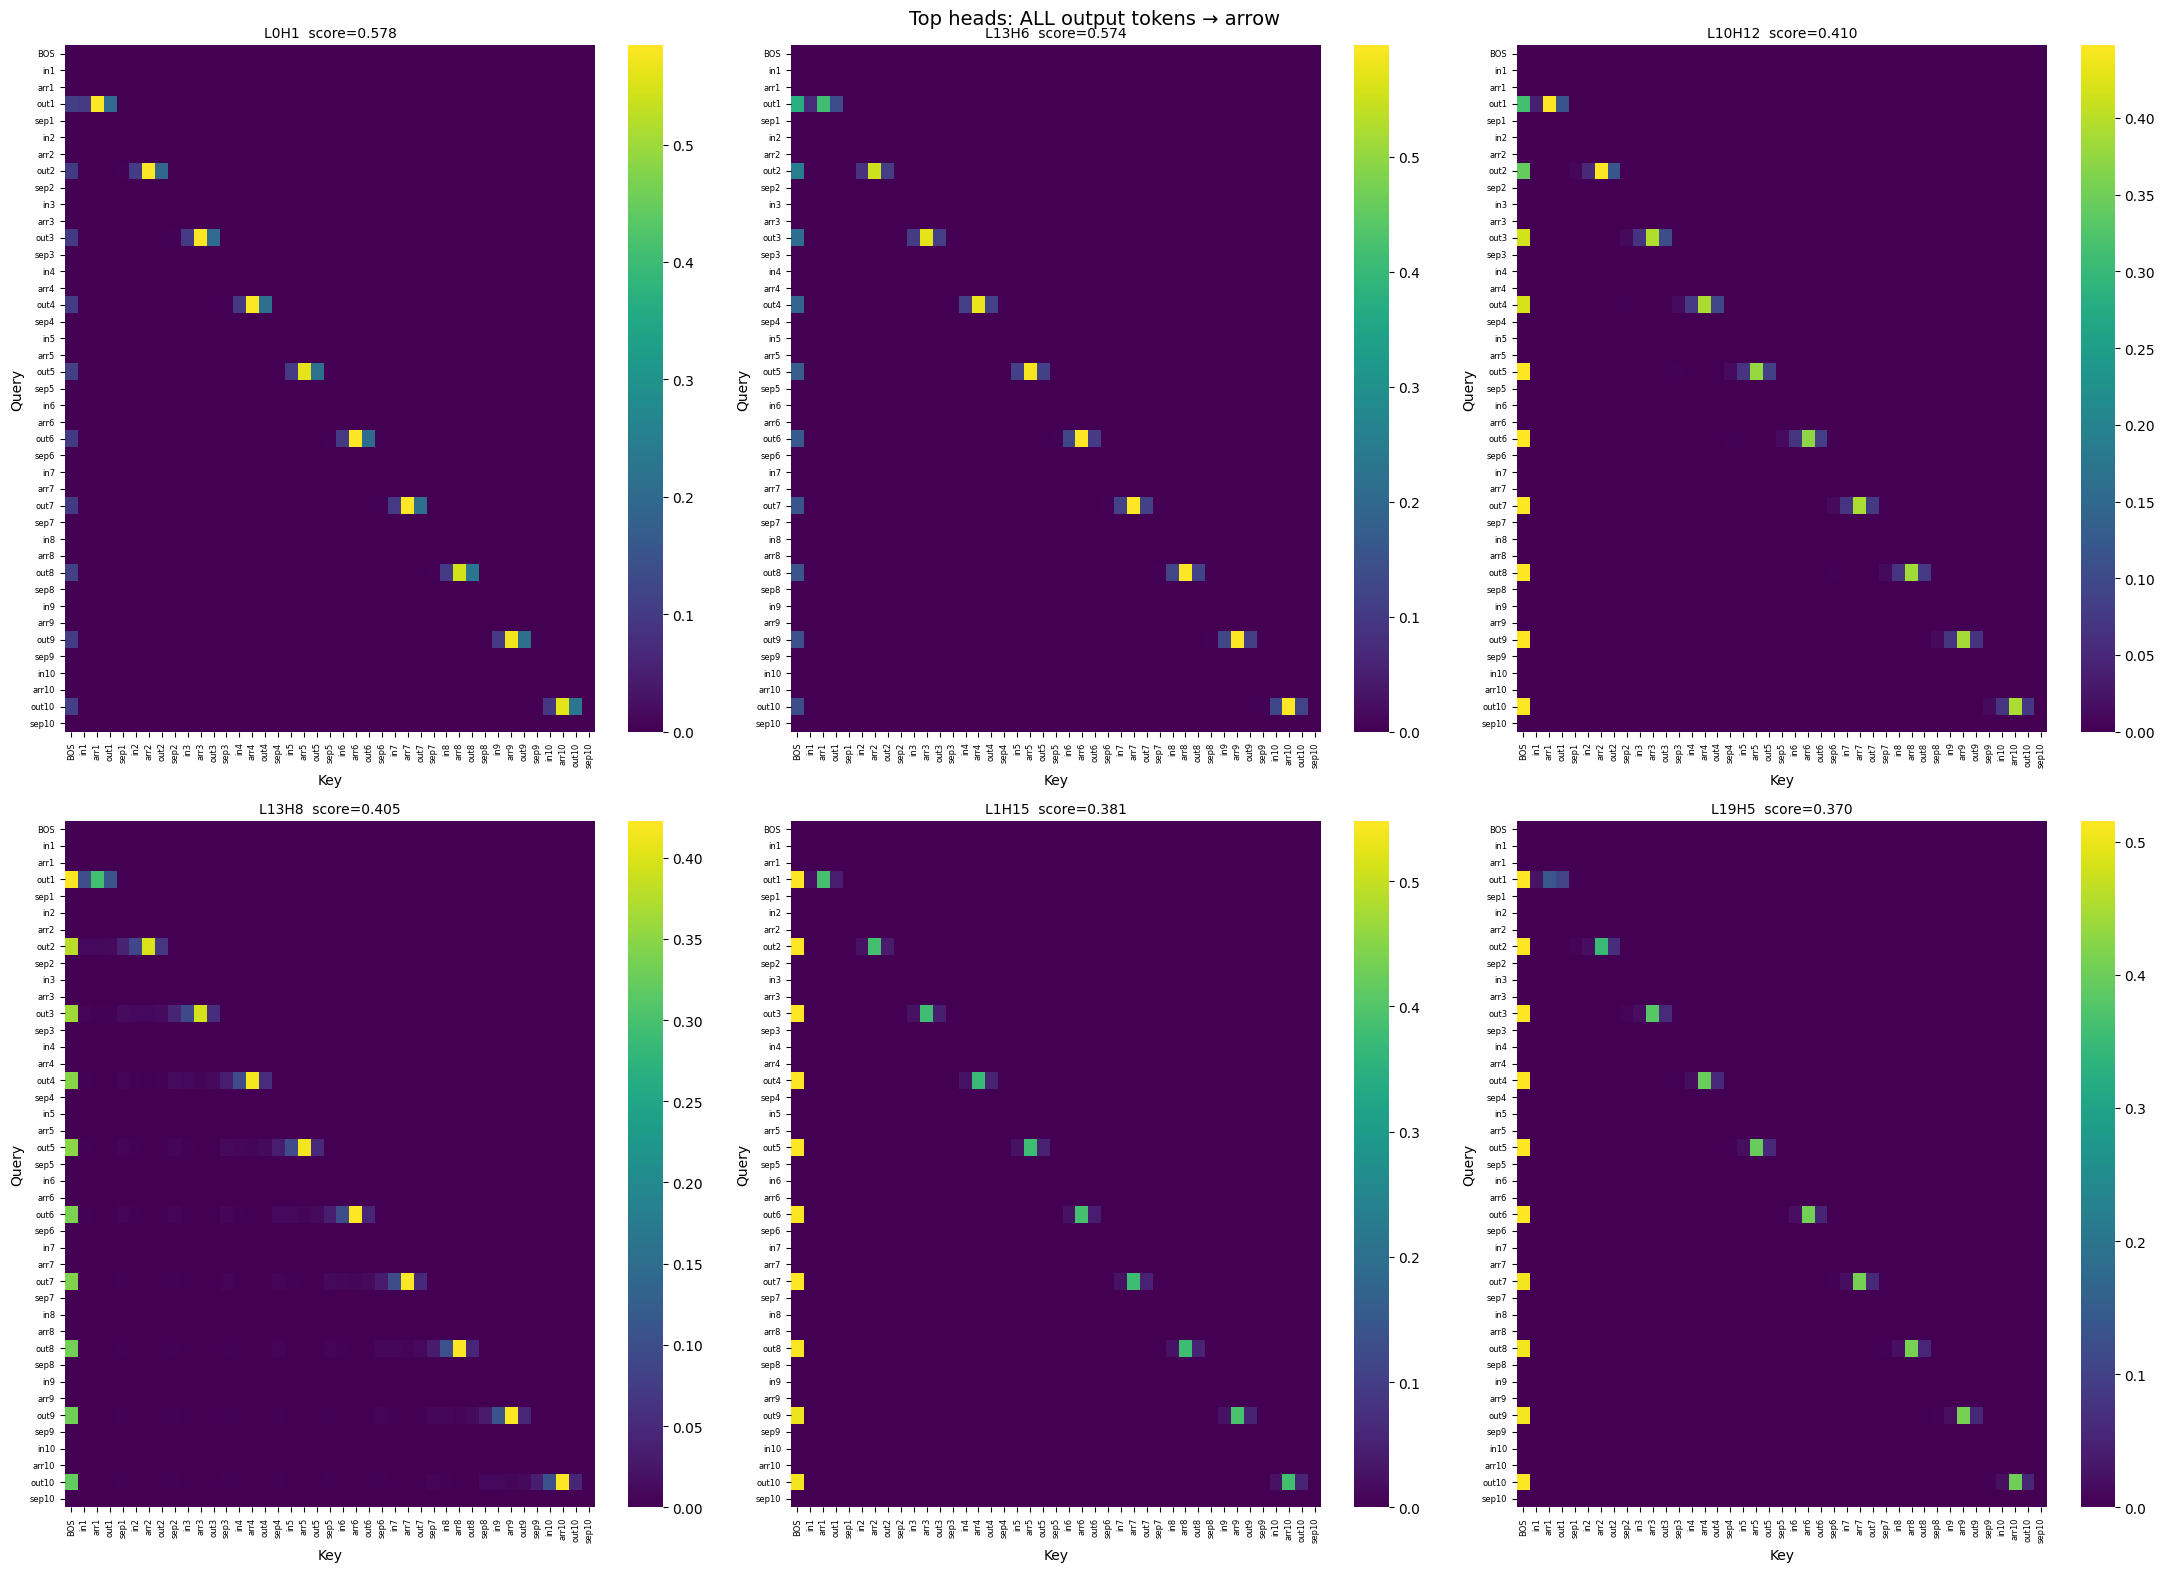

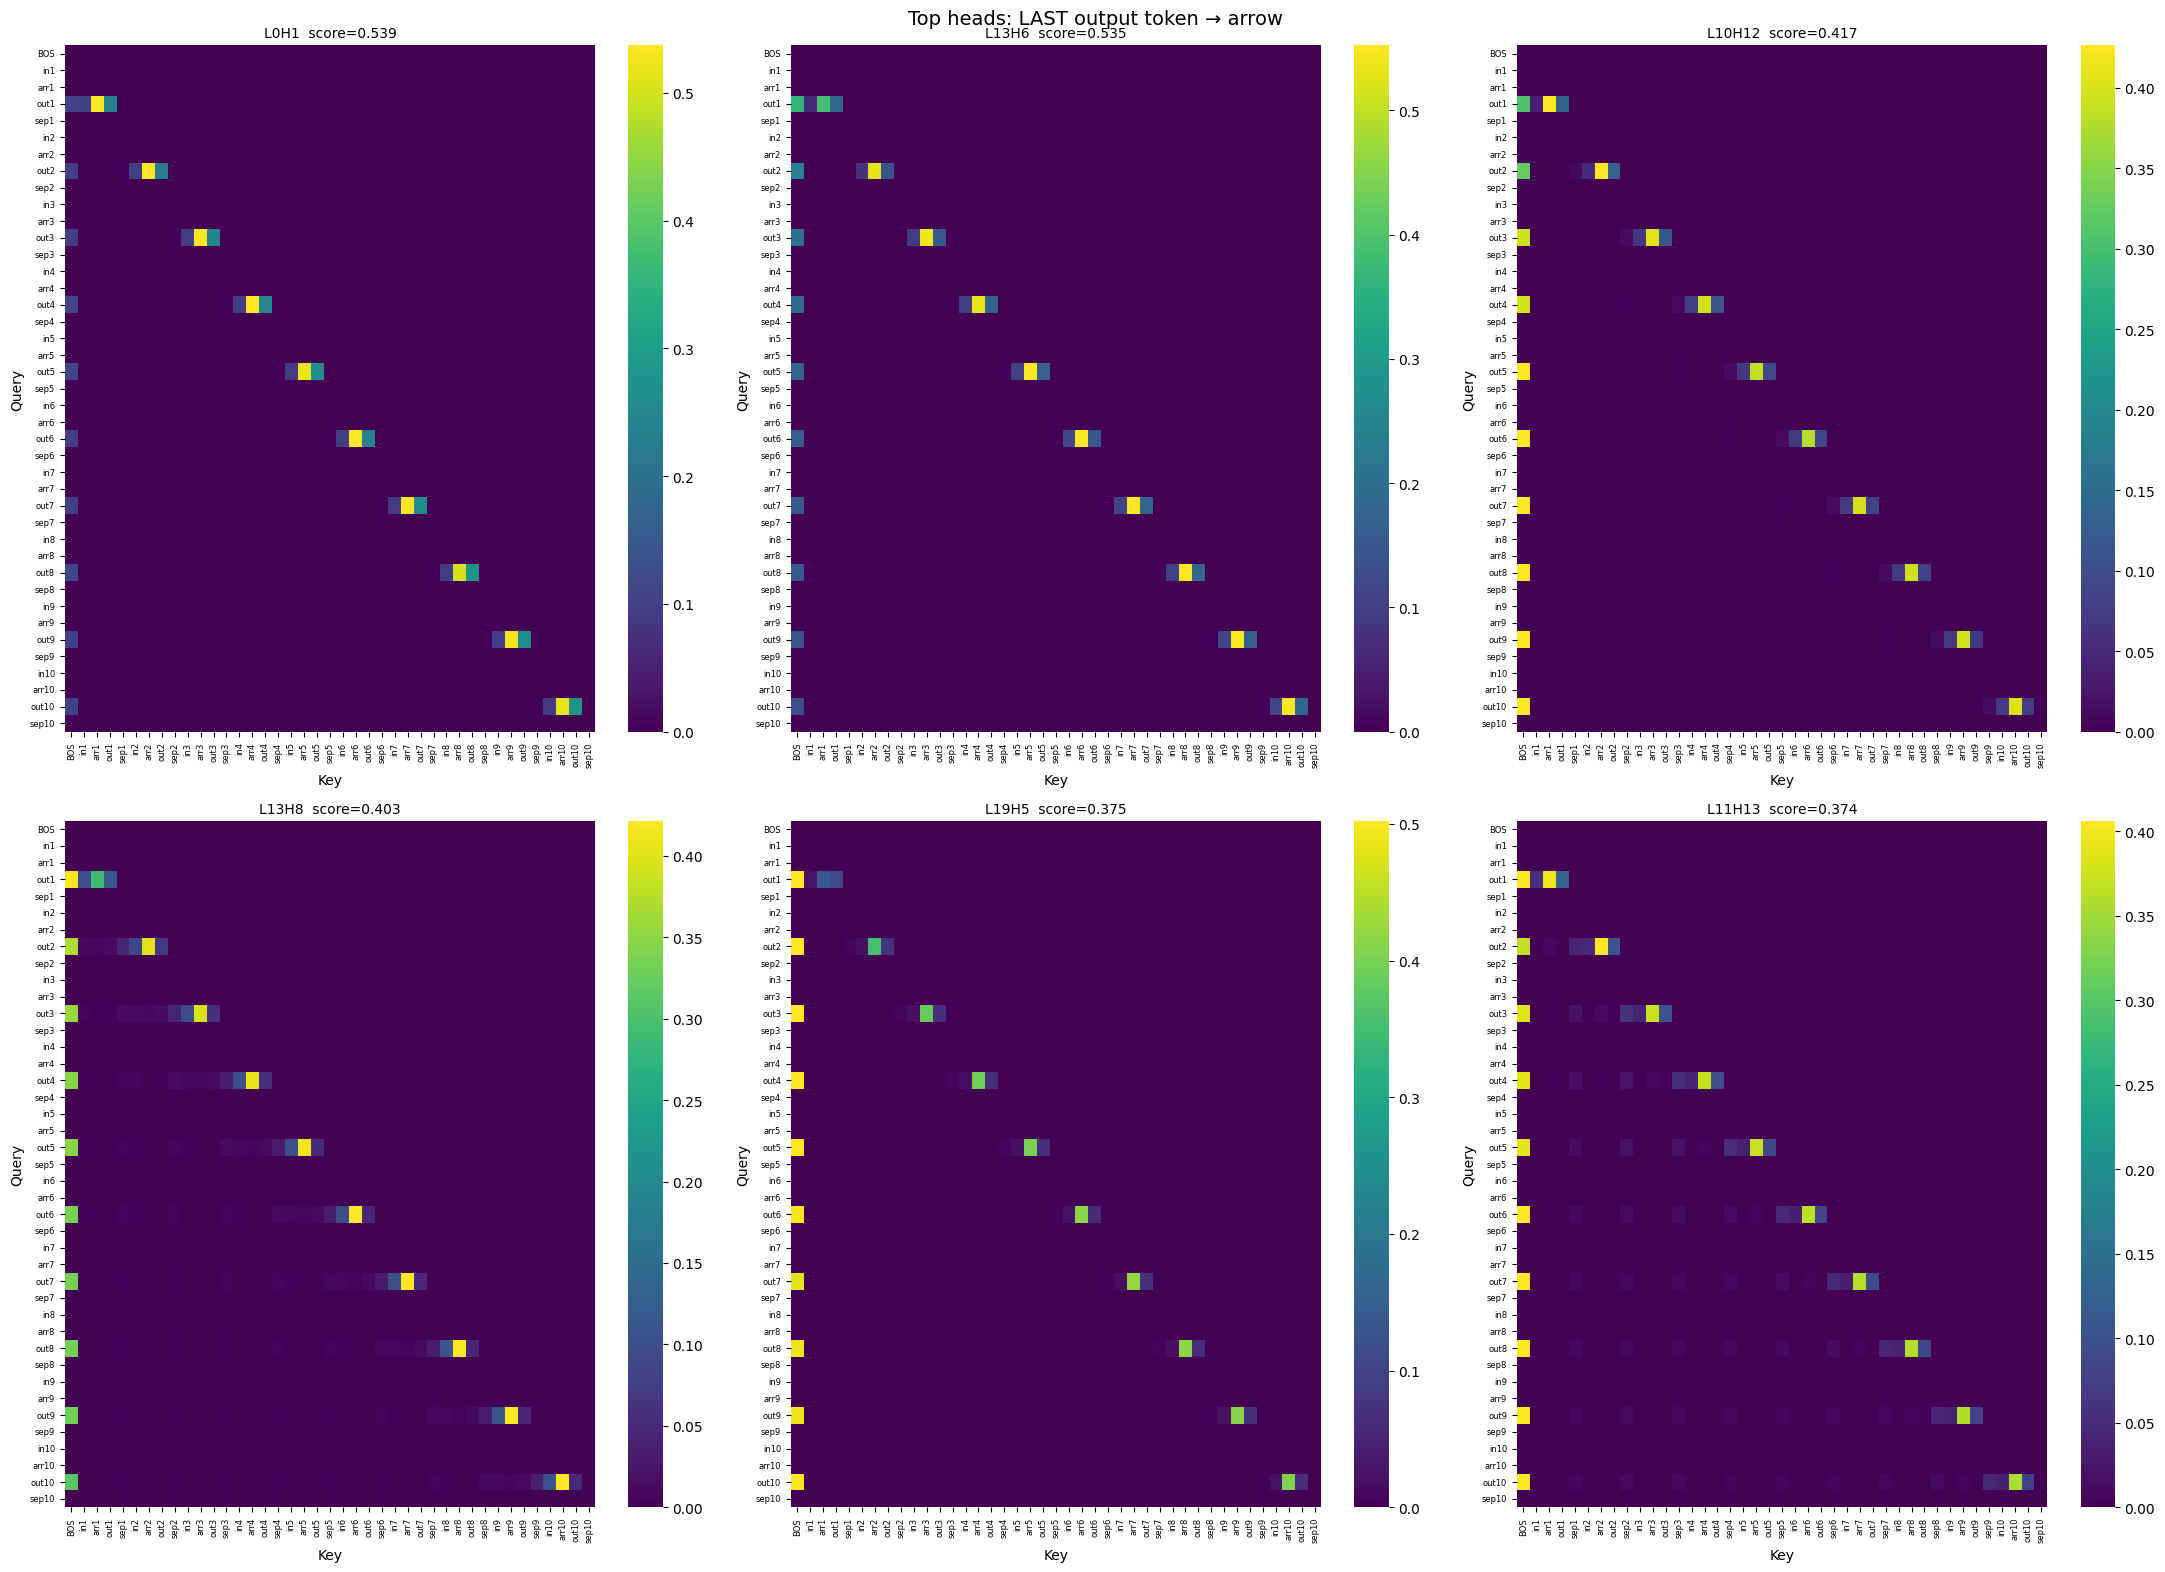

In [21]:
# ============================================================
# Slot-level visualization of top arrow-attending heads
# ============================================================

def plot_top(agg_dict, score, title):
    flat = sorted([(L, h, score[L, h]) for L in range(n_layers) for h in range(n_heads)], key=lambda x: -x[2])
    top = flat[:6]
    fig, axes = plt.subplots(2, 3, figsize=(22, 16))
    for ax, (L, h, sc) in zip(axes.flatten(), top):
        m = agg_dict[(L, h)]
        vmax = np.percentile(m[m > 0], 98) if (m > 0).any() else 1
        sns.heatmap(m, ax=ax, cmap='viridis', cbar=True, vmax=vmax,
                    xticklabels=ref_labels, yticklabels=ref_labels)
        ax.set_title(f'L{L}H{h}  score={sc:.3f}', fontsize=10)
        ax.set_xlabel('Key'); ax.set_ylabel('Query')
        ax.tick_params(axis='x', rotation=90, labelsize=6)
        ax.tick_params(axis='y', rotation=0, labelsize=6)
    fig.suptitle(title, fontsize=14)
    plt.tight_layout(); plt.show()

plot_top(agg_arrow_all,  score_arrow_all,  'Top heads: ALL output tokens → arrow')
plot_top(agg_arrow_last, score_arrow_last, 'Top heads: LAST output token → arrow')

In [24]:
from collections import defaultdict
import time

PERCENTILE = 90
SELECT_SCORE = score_arrow_all
scores_flat = [(L, h, SELECT_SCORE[L, h]) for L in range(n_layers) for h in range(n_heads)]
scores_flat.sort(key=lambda x: -x[2])
k = max(1, int(round(len(scores_flat) * (100 - PERCENTILE) / 100)))
ABLATE_HEADS_ARROW = [(L, h) for L, h, _ in scores_flat[:k]]
ablate_arrow_by_layer = defaultdict(list)
for L, h in ABLATE_HEADS_ARROW:
    ablate_arrow_by_layer[L].append(h)
print(f'Ablating {len(ABLATE_HEADS_ARROW)} arrow-attending heads')

def make_head_ablation_hook(heads, output_positions_set):
    def hook_fn(z, hook):
        for h in heads:
            for p in output_positions_set:
                z[:, p, h, :] = 0
        return z
    return hook_fn

def make_block_attn_hook(out_arr_pairs):
    def hook_fn(pattern, hook):
        for q, kk in out_arr_pairs:
            pattern[:, :, q, kk] = 0
        row_sums = pattern.sum(dim=-1, keepdim=True).clamp(min=1e-9)
        return pattern / row_sums
    return hook_fn

def make_block_final_to_input_hook(input_positions_set, last_pos):
    def hook_fn(pattern, hook):
        for kk in input_positions_set:
            if kk < last_pos:
                pattern[:, :, last_pos, kk] = 0
        row_sums = pattern.sum(dim=-1, keepdim=True).clamp(min=1e-9)
        return pattern / row_sums
    return hook_fn

icl_orig_a        = defaultdict(int)
icl_star_a        = defaultdict(int)
icl_ablate_a      = defaultdict(int)
icl_block_a       = defaultdict(int)
icl_block_final_a = defaultdict(int)
icl_n_a           = defaultdict(int)

t_start = time.time()
for t_idx, (task_name, splits) in enumerate(all_splits.items()):
    print(f'[{t_idx+1}/{len(all_splits)}] {task_name}')
    
    for pdata in splits['icl_prompts'][:10]:
        demos = pdata['demo_pairs']
        query_input = pdata['query_input']
        correct_answer = pdata.get('query_output')
        if correct_answer is None:
            continue
        
        prompt_orig = pdata['prompt']
        prompt_star = build_icl_prompt([('*', out) for _, out in demos], query_input)
        
        tokens_orig = model.to_tokens(prompt_orig, prepend_bos=True)
        tokens_star = model.to_tokens(prompt_star, prepend_bos=True)
        last_o = tokens_orig.shape[1] - 1
        last_s = tokens_star.shape[1] - 1
        
        per_demo_orig = find_per_demo_positions(model, prompt_orig, demos)
        out_positions = set()
        all_demo_input_positions = set()
        for d in per_demo_orig:
            out_positions.update(d.get('output_positions', []))
            all_demo_input_positions.update(d.get('input_positions', []))
        
        out_arr_pairs = []
        for d in per_demo_orig:
            ins = d.get('input_positions', [])
            outs = d.get('output_positions', [])
            if not ins or not outs: continue
            arrow_positions = list(range(max(ins) + 1, min(outs)))
            for q in outs:
                for kk in arrow_positions:
                    if kk < q:
                        out_arr_pairs.append((q, kk))
        
        # 1. Original
        with torch.no_grad():
            logits = model(tokens_orig)[0, last_o]
        icl_orig_a[task_name] += int(check_correct(model, logits, correct_answer))
        
        # 2. Star
        with torch.no_grad():
            logits = model(tokens_star)[0, last_s]
        icl_star_a[task_name] += int(check_correct(model, logits, correct_answer))
        
        # 3. Head ablation at output positions
        head_hooks = [(f'blocks.{L}.attn.hook_z', make_head_ablation_hook(heads, out_positions))
                      for L, heads in ablate_arrow_by_layer.items()]
        with torch.no_grad(), model.hooks(fwd_hooks=head_hooks):
            logits = model(tokens_orig)[0, last_o]
        icl_ablate_a[task_name] += int(check_correct(model, logits, correct_answer))
        
        # 4. Attention knockout output→arrow at every layer
        block_hooks = [(f'blocks.{L}.attn.hook_pattern', make_block_attn_hook(out_arr_pairs))
                       for L in range(n_layers)]
        with torch.no_grad(), model.hooks(fwd_hooks=block_hooks):
            logits = model(tokens_orig)[0, last_o]
        icl_block_a[task_name] += int(check_correct(model, logits, correct_answer))
        
        # 5. Block final position → all demo input positions
        block_final_hooks = [(f'blocks.{L}.attn.hook_pattern',
                              make_block_final_to_input_hook(all_demo_input_positions, last_o))
                             for L in range(n_layers)]
        with torch.no_grad(), model.hooks(fwd_hooks=block_final_hooks):
            logits = model(tokens_orig)[0, last_o]
        icl_block_final_a[task_name] += int(check_correct(model, logits, correct_answer))
        
        icl_n_a[task_name] += 1
        torch.cuda.empty_cache()

print(f'Done in {time.time() - t_start:.0f}s')

Ablating 67 arrow-attending heads
[1/20] knowledge/country_capital
[2/20] knowledge/football_player_position
[3/20] knowledge/location_continent
[4/20] knowledge/location_country
[5/20] knowledge/location_language
[6/20] knowledge/location_religion
[7/20] knowledge/person_language
[8/20] knowledge/person_profession
[9/20] linguistic/antonyms
[10/20] linguistic/plural_singular
[11/20] linguistic/present_simple_gerund
[12/20] linguistic/present_simple_past_perfect
[13/20] linguistic/present_simple_past_simple
[14/20] linguistic/singular_plural
[15/20] translation/en_es
[16/20] translation/en_fr
[17/20] translation/en_it
[18/20] translation/es_en
[19/20] translation/fr_en
[20/20] translation/it_en
Done in 46s



=== Aggregate ICL accuracy: arrow + final-position interventions (n=200) ===
  Original                            0.835  [0.777, 0.880]
  Star inputs                         0.330  [0.269, 0.398]
  Head ablation (top 10% arrow)       0.825  [0.766, 0.871]
  Attention knockout out→arrow        0.780  [0.718, 0.832]
  Block final→demo inputs             0.830  [0.772, 0.876]

Task                                         Orig     Star    HeadAbl   BlockAttn
--------------------------------------------------------------------------------
linguistic/present_simple_gerund             1.00     0.10       1.00        1.00
knowledge/location_religion                  1.00     0.30       1.00        0.50
linguistic/antonyms                          1.00     0.30       1.00        1.00
linguistic/plural_singular                   1.00     0.30       1.00        1.00
linguistic/present_simple_past_perfect       1.00     0.30       0.90        0.90
translation/it_en                            0.9

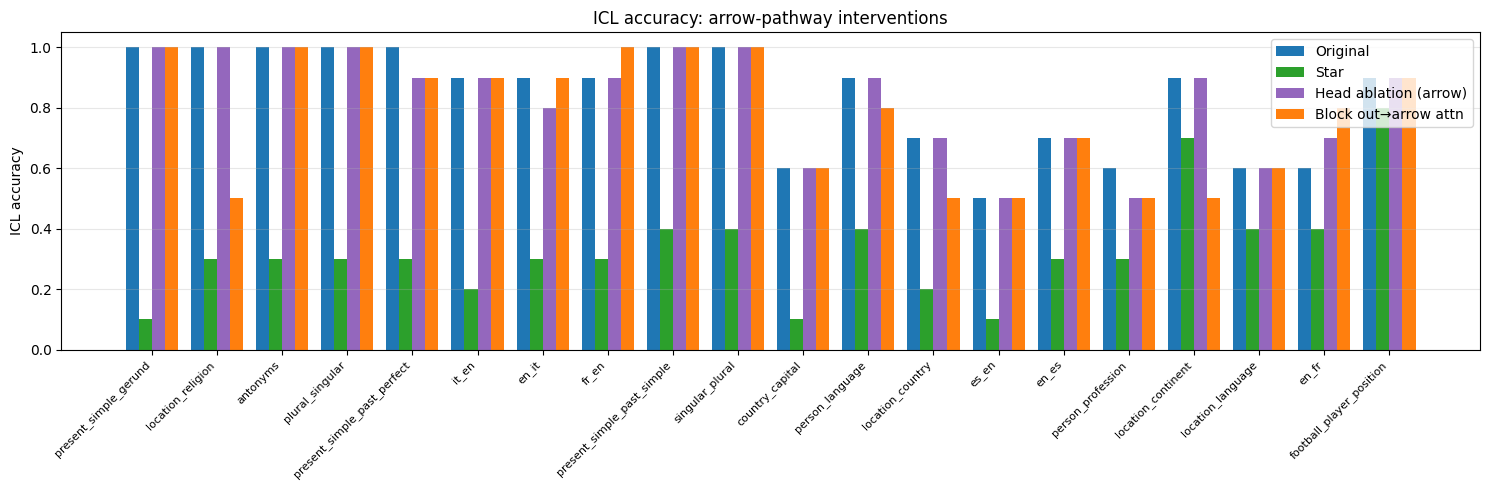

In [25]:
from math import sqrt
Z = 1.96

def wilson(k, n):
    if n == 0: return 0, 0, 0
    p = k / n
    denom = 1 + Z**2/n
    center = (p + Z**2/(2*n)) / denom
    half = Z * sqrt(p*(1-p)/n + Z**2/(4*n**2)) / denom
    return p, max(0, center-half), min(1, center+half)

total_n = sum(icl_n_a.values())
print(f'\n=== Aggregate ICL accuracy: arrow + final-position interventions (n={total_n}) ===')
for label, k_total in [('Original', sum(icl_orig_a.values())),
                       ('Star inputs', sum(icl_star_a.values())),
                       ('Head ablation (top 10% arrow)', sum(icl_ablate_a.values())),
                       ('Attention knockout out→arrow', sum(icl_block_a.values())),
                       ('Block final→demo inputs', sum(icl_block_final_a.values()))]:
    p, lo, hi = wilson(k_total, total_n)
    print(f'  {label:<35} {p:.3f}  [{lo:.3f}, {hi:.3f}]')

# Per-task table sorted by orig→star drop
print(f'\n{"Task":<40} {"Orig":>8} {"Star":>8} {"HeadAbl":>10} {"BlockAttn":>11}')
print('-' * 80)
rows = [(t, icl_orig_a[t]/icl_n_a[t], icl_star_a[t]/icl_n_a[t],
         icl_ablate_a[t]/icl_n_a[t], icl_block_a[t]/icl_n_a[t])
        for t in sorted(icl_n_a.keys())]
for t, o, s, a, b in sorted(rows, key=lambda r: -(r[1]-r[2])):
    print(f'{t:<40} {o:>8.2f} {s:>8.2f} {a:>10.2f} {b:>11.2f}')

# Bar plot
import matplotlib.pyplot as plt
rows_sorted = sorted(rows, key=lambda r: -(r[1]-r[2]))
labels_short = [t.split('/')[-1] for t, *_ in rows_sorted]
x = np.arange(len(rows_sorted)); w = 0.2
fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(x - 1.5*w, [r[1] for r in rows_sorted], w, label='Original', color='tab:blue')
ax.bar(x - 0.5*w, [r[2] for r in rows_sorted], w, label='Star', color='tab:green')
ax.bar(x + 0.5*w, [r[3] for r in rows_sorted], w, label='Head ablation (arrow)', color='tab:purple')
ax.bar(x + 1.5*w, [r[4] for r in rows_sorted], w, label='Block out→arrow attn', color='tab:orange')
ax.set_xticks(x); ax.set_xticklabels(labels_short, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('ICL accuracy'); ax.set_ylim(0, 1.05); ax.legend()
ax.set_title('ICL accuracy: arrow-pathway interventions')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

## Random words as input

In [26]:
from collections import defaultdict
import time, random

# Pool of common single-token English nouns unrelated to any Hendel task
# (no countries, capitals, languages, professions, numbers, body parts, tenses)
RANDOM_POOL_RAW = [
    'table', 'chair', 'window', 'pencil', 'bottle', 'mountain', 'river',
    'cloud', 'engine', 'mirror', 'pillow', 'basket', 'ladder', 'candle',
    'garden', 'forest', 'ocean', 'desert', 'planet', 'tower', 'bridge',
    'castle', 'temple', 'kitchen', 'helmet', 'shovel', 'hammer', 'feather',
    'crystal', 'dragon', 'shadow', 'thunder', 'whisper', 'echo', 'horizon',
]

# Filter to ones that are reliably single-token with leading space
RANDOM_POOL = []
for w in RANDOM_POOL_RAW:
    toks = model.to_tokens(' ' + w, prepend_bos=False)[0]
    if len(toks) == 1:
        RANDOM_POOL.append(w)
print(f'{len(RANDOM_POOL)} single-token random words available')

icl_orig_r   = defaultdict(int)
icl_star_r   = defaultdict(int)
icl_random_r = defaultdict(int)
icl_n_r      = defaultdict(int)

rng = random.Random(42)

t_start = time.time()
for t_idx, (task_name, splits) in enumerate(all_splits.items()):
    print(f'[{t_idx+1}/{len(all_splits)}] {task_name}')
    
    for pdata in splits['icl_prompts'][:10]:
        demos = pdata['demo_pairs']
        query_input = pdata['query_input']
        correct_answer = pdata.get('query_output')
        if correct_answer is None:
            continue
        
        prompt_orig = pdata['prompt']
        prompt_star = build_icl_prompt([('*', out) for _, out in demos], query_input)
        
        # Random: each demo gets a different random word from the pool
        random_inputs = rng.sample(RANDOM_POOL, len(demos))
        prompt_random = build_icl_prompt(list(zip(random_inputs, [out for _, out in demos])), query_input)
        
        tokens_orig   = model.to_tokens(prompt_orig,   prepend_bos=True)
        tokens_star   = model.to_tokens(prompt_star,   prepend_bos=True)
        tokens_random = model.to_tokens(prompt_random, prepend_bos=True)
        
        last_o = tokens_orig.shape[1]   - 1
        last_s = tokens_star.shape[1]   - 1
        last_r = tokens_random.shape[1] - 1
        
        with torch.no_grad():
            logits = model(tokens_orig)[0, last_o]
        icl_orig_r[task_name] += int(check_correct(model, logits, correct_answer))
        
        with torch.no_grad():
            logits = model(tokens_star)[0, last_s]
        icl_star_r[task_name] += int(check_correct(model, logits, correct_answer))
        
        with torch.no_grad():
            logits = model(tokens_random)[0, last_r]
        icl_random_r[task_name] += int(check_correct(model, logits, correct_answer))
        
        icl_n_r[task_name] += 1
        torch.cuda.empty_cache()

print(f'Done in {time.time() - t_start:.0f}s')

35 single-token random words available
[1/20] knowledge/country_capital
[2/20] knowledge/football_player_position
[3/20] knowledge/location_continent
[4/20] knowledge/location_country
[5/20] knowledge/location_language
[6/20] knowledge/location_religion
[7/20] knowledge/person_language
[8/20] knowledge/person_profession
[9/20] linguistic/antonyms
[10/20] linguistic/plural_singular
[11/20] linguistic/present_simple_gerund
[12/20] linguistic/present_simple_past_perfect
[13/20] linguistic/present_simple_past_simple
[14/20] linguistic/singular_plural
[15/20] translation/en_es
[16/20] translation/en_fr
[17/20] translation/en_it
[18/20] translation/es_en
[19/20] translation/fr_en
[20/20] translation/it_en
Done in 23s



=== Aggregate ICL accuracy: random-word control (n=200) ===
  Original                  0.835  [0.777, 0.880]
  Star inputs               0.330  [0.269, 0.398]
  Random word inputs        0.265  [0.209, 0.330]

Task                                         Orig     Star   Random
--------------------------------------------------------------------
linguistic/present_simple_gerund             1.00     0.10     0.10
knowledge/location_religion                  1.00     0.30     0.80
linguistic/antonyms                          1.00     0.30     0.00
linguistic/plural_singular                   1.00     0.30     0.20
linguistic/present_simple_past_perfect       1.00     0.30     0.10
translation/it_en                            0.90     0.20     0.10
translation/en_it                            0.90     0.30     0.30
translation/fr_en                            0.90     0.30     0.00
linguistic/present_simple_past_simple        1.00     0.40     0.20
linguistic/singular_plural             

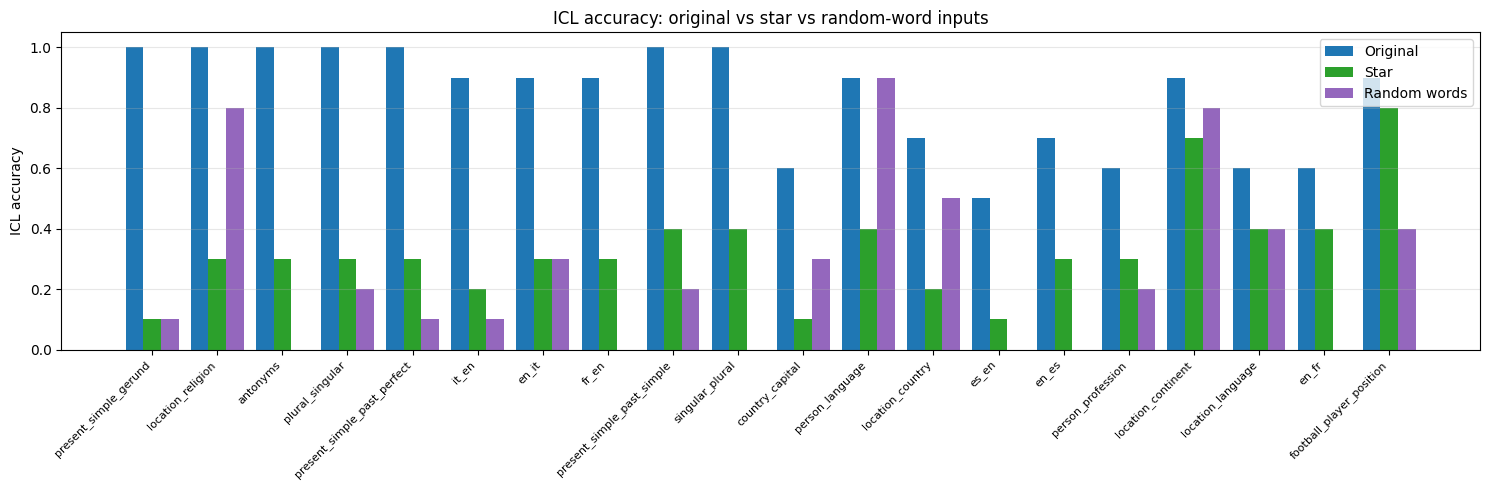

In [27]:
from math import sqrt
Z = 1.96

def wilson(k, n):
    if n == 0: return 0, 0, 0
    p = k / n
    denom = 1 + Z**2/n
    center = (p + Z**2/(2*n)) / denom
    half = Z * sqrt(p*(1-p)/n + Z**2/(4*n**2)) / denom
    return p, max(0, center-half), min(1, center+half)

total_n = sum(icl_n_r.values())
print(f'\n=== Aggregate ICL accuracy: random-word control (n={total_n}) ===')
for label, k_total in [('Original', sum(icl_orig_r.values())),
                       ('Star inputs', sum(icl_star_r.values())),
                       ('Random word inputs', sum(icl_random_r.values()))]:
    p, lo, hi = wilson(k_total, total_n)
    print(f'  {label:<25} {p:.3f}  [{lo:.3f}, {hi:.3f}]')

# Per-task table
print(f'\n{"Task":<40} {"Orig":>8} {"Star":>8} {"Random":>8}')
print('-' * 68)
rows = [(t, icl_orig_r[t]/icl_n_r[t], icl_star_r[t]/icl_n_r[t], icl_random_r[t]/icl_n_r[t])
        for t in sorted(icl_n_r.keys())]
for t, o, s, r in sorted(rows, key=lambda r: -(r[1]-r[2])):
    print(f'{t:<40} {o:>8.2f} {s:>8.2f} {r:>8.2f}')

# Bar plot
import matplotlib.pyplot as plt
rows_sorted = sorted(rows, key=lambda r: -(r[1]-r[2]))
labels_short = [t.split('/')[-1] for t, *_ in rows_sorted]
x = np.arange(len(rows_sorted)); w = 0.27
fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(x - w, [r[1] for r in rows_sorted], w, label='Original', color='tab:blue')
ax.bar(x,     [r[2] for r in rows_sorted], w, label='Star',     color='tab:green')
ax.bar(x + w, [r[3] for r in rows_sorted], w, label='Random words', color='tab:purple')
ax.set_xticks(x); ax.set_xticklabels(labels_short, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('ICL accuracy'); ax.set_ylim(0, 1.05); ax.legend()
ax.set_title('ICL accuracy: original vs star vs random-word inputs')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

## Block attention to subsets of everything

In [28]:
from collections import defaultdict
import time

def make_block_out_to_pre_demo_hook(out_to_keys_to_block):
    """Block attention from each output position to a specific set of key positions."""
    def hook_fn(pattern, hook):
        for q, ks in out_to_keys_to_block.items():
            for kk in ks:
                if kk < q:
                    pattern[:, :, q, kk] = 0
        row_sums = pattern.sum(dim=-1, keepdim=True).clamp(min=1e-9)
        return pattern / row_sums
    return hook_fn

icl_orig_b      = defaultdict(int)
icl_random_b    = defaultdict(int)
icl_within_b    = defaultdict(int)  # block output→anything outside its own demo
icl_self_b      = defaultdict(int)  # block output→anything except itself and BOS
icl_n_b         = defaultdict(int)

import random as _random
rng = _random.Random(42)
RANDOM_POOL = ['table', 'chair', 'window', 'bottle', 'mountain', 'river', 'cloud', 
               'engine', 'mirror', 'pillow', 'basket', 'ladder', 'candle', 'garden',
               'forest', 'ocean', 'desert', 'planet', 'tower', 'bridge', 'castle',
               'temple', 'kitchen', 'helmet', 'shovel', 'hammer', 'feather']
RANDOM_POOL = [w for w in RANDOM_POOL if len(model.to_tokens(' '+w, prepend_bos=False)[0]) == 1]

t_start = time.time()
for t_idx, (task_name, splits) in enumerate(all_splits.items()):
    print(f'[{t_idx+1}/{len(all_splits)}] {task_name}')
    
    for pdata in splits['icl_prompts'][:10]:
        demos = pdata['demo_pairs']
        query_input = pdata['query_input']
        correct_answer = pdata.get('query_output')
        if correct_answer is None: continue
        
        prompt_orig = pdata['prompt']
        random_inputs = rng.sample(RANDOM_POOL, len(demos))
        prompt_random = build_icl_prompt(list(zip(random_inputs, [out for _, out in demos])), query_input)
        
        tokens_orig   = model.to_tokens(prompt_orig,   prepend_bos=True)
        tokens_random = model.to_tokens(prompt_random, prepend_bos=True)
        last_o = tokens_orig.shape[1]   - 1
        last_r = tokens_random.shape[1] - 1
        seq_o  = tokens_orig.shape[1]
        
        per_demo_orig = find_per_demo_positions(model, prompt_orig, demos)
        
        # Build per-output-position blocking sets for two conditions:
        # WITHIN: output position can only attend to keys in its own demo (in/arr/out within same demo)
        # SELF:   output position can only attend to itself and BOS
        within_block = {}  # q -> set of keys to block
        self_block   = {}
        
        # First, compute the span of each demo (all positions belonging to it)
        demo_spans = []
        for d in per_demo_orig:
            ins  = d.get('input_positions', [])
            outs = d.get('output_positions', [])
            if not ins or not outs: continue
            lo = min(ins)
            hi = max(outs) + 1  # include separator? we'll be permissive — only out to hi
            # Be conservative: own_demo = [first input token .. last output token], inclusive
            demo_spans.append((lo, max(outs)))
        
        for d_idx, d in enumerate(per_demo_orig):
            outs = d.get('output_positions', [])
            if not outs: continue
            own_lo, own_hi = demo_spans[d_idx]
            for q in outs:
                # WITHIN: block all key positions outside own demo (and not BOS)
                blocked_within = [k for k in range(seq_o) 
                                  if k != 0 and not (own_lo <= k <= own_hi)]
                within_block[q] = blocked_within
                # SELF: block everything except self and BOS
                blocked_self = [k for k in range(seq_o) if k != 0 and k != q]
                self_block[q] = blocked_self
        
        # 1. Original
        with torch.no_grad():
            logits = model(tokens_orig)[0, last_o]
        icl_orig_b[task_name] += int(check_correct(model, logits, correct_answer))
        
        # 2. Random words baseline
        with torch.no_grad():
            logits = model(tokens_random)[0, last_r]
        icl_random_b[task_name] += int(check_correct(model, logits, correct_answer))
        
        # 3. Block output → outside-own-demo
        within_hooks = [(f'blocks.{L}.attn.hook_pattern', make_block_out_to_pre_demo_hook(within_block))
                        for L in range(n_layers)]
        with torch.no_grad(), model.hooks(fwd_hooks=within_hooks):
            logits = model(tokens_orig)[0, last_o]
        icl_within_b[task_name] += int(check_correct(model, logits, correct_answer))
        
        # 4. Block output → everything except self and BOS
        self_hooks = [(f'blocks.{L}.attn.hook_pattern', make_block_out_to_pre_demo_hook(self_block))
                      for L in range(n_layers)]
        with torch.no_grad(), model.hooks(fwd_hooks=self_hooks):
            logits = model(tokens_orig)[0, last_o]
        icl_self_b[task_name] += int(check_correct(model, logits, correct_answer))
        
        icl_n_b[task_name] += 1
        torch.cuda.empty_cache()

print(f'Done in {time.time() - t_start:.0f}s')

[1/20] knowledge/country_capital
[2/20] knowledge/football_player_position
[3/20] knowledge/location_continent
[4/20] knowledge/location_country
[5/20] knowledge/location_language
[6/20] knowledge/location_religion
[7/20] knowledge/person_language
[8/20] knowledge/person_profession
[9/20] linguistic/antonyms
[10/20] linguistic/plural_singular
[11/20] linguistic/present_simple_gerund
[12/20] linguistic/present_simple_past_perfect
[13/20] linguistic/present_simple_past_simple
[14/20] linguistic/singular_plural
[15/20] translation/en_es
[16/20] translation/en_fr
[17/20] translation/en_it
[18/20] translation/es_en
[19/20] translation/fr_en
[20/20] translation/it_en
Done in 73s


In [29]:
from math import sqrt
Z = 1.96
def wilson(k, n):
    if n == 0: return 0, 0, 0
    p = k / n
    denom = 1 + Z**2/n
    center = (p + Z**2/(2*n)) / denom
    half = Z * sqrt(p*(1-p)/n + Z**2/(4*n**2)) / denom
    return p, max(0, center-half), min(1, center+half)

total_n = sum(icl_n_b.values())
print(f'\n=== Output position attention isolation (n={total_n}) ===')
for label, k_total in [('Original', sum(icl_orig_b.values())),
                       ('Random word baseline', sum(icl_random_b.values())),
                       ('Block out→outside-own-demo', sum(icl_within_b.values())),
                       ('Block out→everything but self+BOS', sum(icl_self_b.values()))]:
    p, lo, hi = wilson(k_total, total_n)
    print(f'  {label:<38} {p:.3f}  [{lo:.3f}, {hi:.3f}]')

print(f'\n{"Task":<40} {"Orig":>8} {"Random":>8} {"WithinDemo":>12} {"SelfOnly":>10}')
print('-' * 82)
rows = [(t, icl_orig_b[t]/icl_n_b[t], icl_random_b[t]/icl_n_b[t],
         icl_within_b[t]/icl_n_b[t], icl_self_b[t]/icl_n_b[t])
        for t in sorted(icl_n_b.keys())]
for t, o, r, w, s in sorted(rows, key=lambda x: -(x[1]-x[2])):
    print(f'{t:<40} {o:>8.2f} {r:>8.2f} {w:>12.2f} {s:>10.2f}')


=== Output position attention isolation (n=200) ===
  Original                               0.835  [0.777, 0.880]
  Random word baseline                   0.280  [0.222, 0.346]
  Block out→outside-own-demo             0.785  [0.723, 0.836]
  Block out→everything but self+BOS      0.140  [0.099, 0.195]

Task                                         Orig   Random   WithinDemo   SelfOnly
----------------------------------------------------------------------------------
linguistic/antonyms                          1.00     0.00         1.00       0.00
linguistic/singular_plural                   1.00     0.00         1.00       0.00
linguistic/present_simple_gerund             1.00     0.10         1.00       0.00
translation/en_it                            0.90     0.00         0.80       0.00
linguistic/plural_singular                   1.00     0.20         1.00       0.00
linguistic/present_simple_past_perfect       1.00     0.20         0.80       0.00
linguistic/present_simple_past

##

In [30]:
from collections import defaultdict
import time
import random as _random

def make_block_out_to_positions_hook(block_map):
    """block_map: {output_q_pos: set of key positions to zero}"""
    def hook_fn(pattern, hook):
        for q, ks in block_map.items():
            for kk in ks:
                if kk < q:
                    pattern[:, :, q, kk] = 0
        row_sums = pattern.sum(dim=-1, keepdim=True).clamp(min=1e-9)
        return pattern / row_sums
    return hook_fn

icl_orig_c     = defaultdict(int)
icl_random_c   = defaultdict(int)
icl_in_only_c  = defaultdict(int)  # block out → own-demo input only
icl_arr_only_c = defaultdict(int)  # block out → own-demo arrow only
icl_both_c     = defaultdict(int)  # block out → own-demo input AND arrow jointly
icl_n_c        = defaultdict(int)

rng = _random.Random(42)
RANDOM_POOL = ['table', 'chair', 'window', 'bottle', 'mountain', 'river', 'cloud',
               'engine', 'mirror', 'pillow', 'basket', 'ladder', 'candle', 'garden',
               'forest', 'ocean', 'desert', 'planet', 'tower', 'bridge', 'castle',
               'temple', 'kitchen', 'helmet', 'shovel', 'hammer', 'feather']
RANDOM_POOL = [w for w in RANDOM_POOL if len(model.to_tokens(' '+w, prepend_bos=False)[0]) == 1]

t_start = time.time()
for t_idx, (task_name, splits) in enumerate(all_splits.items()):
    print(f'[{t_idx+1}/{len(all_splits)}] {task_name}')
    
    for pdata in splits['icl_prompts'][:10]:
        demos = pdata['demo_pairs']
        query_input = pdata['query_input']
        correct_answer = pdata.get('query_output')
        if correct_answer is None: continue
        
        prompt_orig = pdata['prompt']
        random_inputs = rng.sample(RANDOM_POOL, len(demos))
        prompt_random = build_icl_prompt(list(zip(random_inputs, [out for _, out in demos])), query_input)
        
        tokens_orig   = model.to_tokens(prompt_orig,   prepend_bos=True)
        tokens_random = model.to_tokens(prompt_random, prepend_bos=True)
        last_o = tokens_orig.shape[1]   - 1
        last_r = tokens_random.shape[1] - 1
        
        per_demo_orig = find_per_demo_positions(model, prompt_orig, demos)
        
        # Build three blocking maps
        in_only_map  = {}  # out → own-demo input positions
        arr_only_map = {}  # out → own-demo arrow positions
        both_map     = {}  # out → own-demo input + arrow positions
        
        for d in per_demo_orig:
            ins  = d.get('input_positions', [])
            outs = d.get('output_positions', [])
            if not ins or not outs: continue
            arrow_positions = list(range(max(ins) + 1, min(outs)))
            for q in outs:
                in_only_map[q]  = set(ins)
                arr_only_map[q] = set(arrow_positions)
                both_map[q]     = set(ins) | set(arrow_positions)
        
        # 1. Original
        with torch.no_grad():
            logits = model(tokens_orig)[0, last_o]
        icl_orig_c[task_name] += int(check_correct(model, logits, correct_answer))
        
        # 2. Random baseline
        with torch.no_grad():
            logits = model(tokens_random)[0, last_r]
        icl_random_c[task_name] += int(check_correct(model, logits, correct_answer))
        
        # 3. Block out → own-demo input only
        hooks = [(f'blocks.{L}.attn.hook_pattern', make_block_out_to_positions_hook(in_only_map))
                 for L in range(n_layers)]
        with torch.no_grad(), model.hooks(fwd_hooks=hooks):
            logits = model(tokens_orig)[0, last_o]
        icl_in_only_c[task_name] += int(check_correct(model, logits, correct_answer))
        
        # 4. Block out → own-demo arrow only
        hooks = [(f'blocks.{L}.attn.hook_pattern', make_block_out_to_positions_hook(arr_only_map))
                 for L in range(n_layers)]
        with torch.no_grad(), model.hooks(fwd_hooks=hooks):
            logits = model(tokens_orig)[0, last_o]
        icl_arr_only_c[task_name] += int(check_correct(model, logits, correct_answer))
        
        # 5. Block out → own-demo input AND arrow jointly
        hooks = [(f'blocks.{L}.attn.hook_pattern', make_block_out_to_positions_hook(both_map))
                 for L in range(n_layers)]
        with torch.no_grad(), model.hooks(fwd_hooks=hooks):
            logits = model(tokens_orig)[0, last_o]
        icl_both_c[task_name] += int(check_correct(model, logits, correct_answer))
        
        icl_n_c[task_name] += 1
        torch.cuda.empty_cache()

print(f'Done in {time.time() - t_start:.0f}s')

[1/20] knowledge/country_capital
[2/20] knowledge/football_player_position
[3/20] knowledge/location_continent
[4/20] knowledge/location_country
[5/20] knowledge/location_language
[6/20] knowledge/location_religion
[7/20] knowledge/person_language
[8/20] knowledge/person_profession
[9/20] linguistic/antonyms
[10/20] linguistic/plural_singular
[11/20] linguistic/present_simple_gerund
[12/20] linguistic/present_simple_past_perfect
[13/20] linguistic/present_simple_past_simple
[14/20] linguistic/singular_plural
[15/20] translation/en_es
[16/20] translation/en_fr
[17/20] translation/en_it
[18/20] translation/es_en
[19/20] translation/fr_en
[20/20] translation/it_en
Done in 47s


In [31]:
from math import sqrt
Z = 1.96
def wilson(k, n):
    if n == 0: return 0, 0, 0
    p = k / n
    denom = 1 + Z**2/n
    center = (p + Z**2/(2*n)) / denom
    half = Z * sqrt(p*(1-p)/n + Z**2/(4*n**2)) / denom
    return p, max(0, center-half), min(1, center+half)

total_n = sum(icl_n_c.values())
print(f'\n=== Within-demo input/arrow joint blocking (n={total_n}) ===')
for label, k_total in [('Original', sum(icl_orig_c.values())),
                       ('Random baseline', sum(icl_random_c.values())),
                       ('Block out → in_d only', sum(icl_in_only_c.values())),
                       ('Block out → arr_d only', sum(icl_arr_only_c.values())),
                       ('Block out → (in_d + arr_d) jointly', sum(icl_both_c.values()))]:
    p, lo, hi = wilson(k_total, total_n)
    print(f'  {label:<40} {p:.3f}  [{lo:.3f}, {hi:.3f}]')

print(f'\n{"Task":<40} {"Orig":>7} {"Rand":>7} {"InOnly":>8} {"ArrOnly":>9} {"Both":>7}')
print('-' * 82)
rows = [(t, icl_orig_c[t]/icl_n_c[t], icl_random_c[t]/icl_n_c[t],
         icl_in_only_c[t]/icl_n_c[t], icl_arr_only_c[t]/icl_n_c[t], icl_both_c[t]/icl_n_c[t])
        for t in sorted(icl_n_c.keys())]
for row in sorted(rows, key=lambda x: -(x[1]-x[5])):
    print(f'{row[0]:<40} {row[1]:>7.2f} {row[2]:>7.2f} {row[3]:>8.2f} {row[4]:>9.2f} {row[5]:>7.2f}')


=== Within-demo input/arrow joint blocking (n=200) ===
  Original                                 0.835  [0.777, 0.880]
  Random baseline                          0.280  [0.222, 0.346]
  Block out → in_d only                    0.750  [0.686, 0.805]
  Block out → arr_d only                   0.780  [0.718, 0.832]
  Block out → (in_d + arr_d) jointly       0.340  [0.278, 0.408]

Task                                        Orig    Rand   InOnly   ArrOnly    Both
----------------------------------------------------------------------------------
linguistic/antonyms                         1.00    0.00     0.60      1.00    0.10
linguistic/present_simple_gerund            1.00    0.10     0.90      1.00    0.20
linguistic/present_simple_past_perfect      1.00    0.20     0.70      0.90    0.20
linguistic/present_simple_past_simple       1.00    0.20     0.90      1.00    0.20
translation/en_it                           0.90    0.00     0.80      0.90    0.10
linguistic/plural_singular     